#MAPEO DE SERIES DE TIEMPO DE ANOMALÍAS DE ENOS Y CAUDAL

##DEFINICIONES

In [1]:
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt


# ============================================================
# Mapeo global de permutaciones (predefinido para w=4)
# ============================================================

# Generar todas las permutaciones posibles de (1,2,3,4)
w_fijo = 4
permutaciones = list(itertools.permutations(range(1, w_fijo+1)))
permutaciones.sort()  # Orden lexicográfico para consistencia

# Crear mapeos globales
MAQUINA_ESTADOS = {perm: idx for idx, perm in enumerate(permutaciones)}  # perm -> índice 0-23
INDICE_A_PERM = {idx: perm for idx, perm in enumerate(permutaciones)}  # índice -> perm
NUM_NODOS_GLOBAL = len(permutaciones)  # 24

# ============================================================
# 1. Crear nodos (ordinal patterns) - MODIFICADA
# ============================================================

def crear_ind(x, tamaño_w):
    """
    Devuelve la lista de patrones ordinales mapeados a índices globales.
    Usa el mapeo MAQUINA_ESTADOS para garantizar consistencia.
    """
    x = np.asarray(x)
    N = len(x)
    w = int(tamaño_w)
    if N < w:
        return []

    ind_x1 = []
    for i in range(0, N - w + 1):
        sub = x[i:i+w]

        # Orden de índices de mayor a menor (Small 2013 define orden por "pi_j-th largest")
        order_desc = np.argsort(sub, kind='stable')[::-1]  # índices del mayor al menor

        # Construir ranking: ranks[pos] = 1..w (1 = mayor)
        ranks = np.empty(w, dtype=int)
        ranks[order_desc] = np.arange(1, w+1)

        pat = tuple(ranks.tolist())
        # Mapear a índice global usando MAQUINA_ESTADOS
        idx = MAQUINA_ESTADOS[pat]
        ind_x1.append(idx)

    return ind_x1

# ============================================================
# 2. Crear grafo (ahora PESADO) - MODIFICADA
# ============================================================

def crear_grafo(ind_x1, tamaño_w):
    """
    Construye un grafo NO dirigido y PESADO con 24 nodos fijos.
    La matriz de adyacencia siempre es de 24×24.
    """
    # Crear grafo con todos los nodos posibles (0-23)
    G = nx.Graph()
    for i in range(NUM_NODOS_GLOBAL):
        G.add_node(i)

    # Inicializar diccionario de etiquetas
    nodo_a_sublista = INDICE_A_PERM.copy()  # copia del mapeo global

    # Añadir aristas incrementando peso (transiciones cada w pasos)
    w = int(tamaño_w)
    for i in range(len(ind_x1) - w):
        a = ind_x1[i]  # ya es índice global
        b = ind_x1[i + w]  # ya es índice global
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

    # unique_nodes es el mapeo inverso para compatibilidad
    unique_nodes = {perm: idx for idx, perm in INDICE_A_PERM.items()}

    return G, unique_nodes, nodo_a_sublista

# ============================================================
# 3. Calcular entropía usando matriz de conectividad PESADA - MODIFICADA
# ============================================================

def calcular_entropia(unique_nodes, ind_x1, w):
    """
    Calcula entropía con matriz de adyacencia de 24×24.
    """
    # Inicializar matriz 24×24 (no usa unique_nodes para el tamaño)
    matriz_conectividad = np.zeros((NUM_NODOS_GLOBAL, NUM_NODOS_GLOBAL), dtype=int)

    w_int = int(w)
    # Rellenar matriz con conteos de transiciones
    for i in range(len(ind_x1) - w_int):
        a = ind_x1[i]  # índice global
        b = ind_x1[i + w_int]  # índice global
        matriz_conectividad[a, b] += 1
        matriz_conectividad[b, a] += 1  # red no dirigida

    # sumas por fila = fuerza (grado ponderado)
    sum_m = matriz_conectividad.sum(axis=1)

    mu = []
    for i in range(NUM_NODOS_GLOBAL):
        if sum_m[i] == 0:
            mu.append(0.0)
            continue
        ent = 0.0
        for j in range(NUM_NODOS_GLOBAL):
            if matriz_conectividad[i, j] > 0:
                p = matriz_conectividad[i, j] / sum_m[i]
                ent -= p * np.log2(p)
        mu.append(ent)

    mut = float(np.mean(mu)) if NUM_NODOS_GLOBAL > 0 else 0.0

    return mu, mut, matriz_conectividad




In [2]:
import numpy as np
import networkx as nx
import itertools
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Extraer patrones ordinales (para cualquier w)
# ------------------------------------------------------------
def obtener_patrones(x, w):
    """
    Devuelve una lista de tuplas, cada una es el patrón ordinal (permutación)
    de una ventana deslizante de longitud w sobre la serie x.
    El orden es de mayor a menor, con desempate estable (primero aparece = más pequeño).
    """
    x = np.asarray(x)
    N = len(x)
    if N < w:
        return []
    patrones = []
    for i in range(N - w + 1):
        sub = x[i:i+w]
        # Índices ordenados de mayor a menor (argsort descendente estable)
        order_desc = np.argsort(sub, kind='stable')[::-1]
        # Asignar rangos: 1 al más grande, w al más pequeño
        ranks = np.empty(w, dtype=int)
        ranks[order_desc] = np.arange(1, w+1)
        patrones.append(tuple(ranks))
    return patrones

# ------------------------------------------------------------
# 2. Construir grafo a partir de la lista de patrones
# ------------------------------------------------------------
def construir_grafo(patrones, w):
    """
    Construye un grafo no dirigido y pesado.
    - Nodos: patrones ordinales distintos que aparecen en la serie.
    - Aristas: entre patrones que ocurren en tiempos sucesivos no solapados
               (separados por w pasos). El peso acumula el número de transiciones.
    """
    # Mapear cada patrón único a un índice local
    unique_pat = {}
    for p in patrones:
        if p not in unique_pat:
            unique_pat[p] = len(unique_pat)
    num_nodes = len(unique_pat)

    # Crear grafo con todos los nodos (inicialmente aislados)
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))

    # Añadir aristas con peso (transiciones cada w pasos, sin solapamiento)
    for i in range(len(patrones) - w):
        a = unique_pat[patrones[i]]
        b = unique_pat[patrones[i + w]]
        if G.has_edge(a, b):
            G[a][b]['weight'] += 1
        else:
            G.add_edge(a, b, weight=1)

    # También devolvemos el mapeo inverso (índice -> patrón) por si se necesita
    idx_to_pat = {v: k for k, v in unique_pat.items()}
    return G, idx_to_pat

# ------------------------------------------------------------
# 3. Calcular entropía de la red (promedio de entropías nodales)
# ------------------------------------------------------------
def calcular_entropia_red(G):
    """
    Calcula la entropía nodal promedio para un grafo pesado no dirigido.
    Para cada nodo i: μ(i) = - Σ_j p(i,j) log2 p(i,j), con p(i,j) = peso(i,j) / fuerza(i).
    La entropía total es el promedio sobre todos los nodos.
    Los nodos aislados contribuyen con 0.
    """
    entropias = []
    for node in G.nodes():
        # Obtener pesos de las aristas incidentes
        weights = [G[node][nbr]['weight'] for nbr in G.neighbors(node)]
        strength = sum(weights)
        if strength == 0:
            entropias.append(0.0)
            continue
        # Calcular entropía
        ent = 0.0
        for wgt in weights:
            p = wgt / strength
            ent -= p * np.log2(p)
        entropias.append(ent)
    return np.mean(entropias) if entropias else 0.0

# ------------------------------------------------------------
# 4. Función de optimización de w (adaptada)
# ------------------------------------------------------------
def optimizar_w(x, w_min, w_max):
    """
    Encuentra el valor óptimo de w que maximiza la entropía promedio de la red.

    Parámetros:
        x (list): Serie temporal.
        w_min (int): Valor mínimo de w (inclusive).
        w_max (int): Valor máximo de w (exclusive, como en range).

    Retorna:
        w_optimo (int): w que maximiza la entropía.
    """
    valores_w = range(w_min, w_max)
    entropias = []

    for w in valores_w:
        # 1. Obtener patrones ordinales
        patrones = obtener_patrones(x, w)
        if len(patrones) < w + 1:   # se necesitan al menos dos transiciones
            entropias.append(0.0)
            continue

        # 2. Construir grafo
        G, _ = construir_grafo(patrones, w)

        # 3. Calcular entropía promedio
        ent = calcular_entropia_red(G)
        entropias.append(ent)

    # Encontrar w óptimo
    idx_opt = np.argmax(entropias)
    w_optimo = valores_w[idx_opt]

    # Graficar
    plt.figure(figsize=(8, 5))
    plt.plot(valores_w, entropias, marker='o', linestyle='-', color='black')
    plt.axvline(x=w_optimo, color='r', linestyle='--',
                label=f'$w_{{opt}}$ = {w_optimo}')
    plt.xlabel('Tamaño de ventana w')
    plt.ylabel('Entropía promedio de la red')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})
    plt.show()

    return w_optimo


In [3]:
# Después de crear el grafo:
def contar_nodos_activos(G):
    """
    Cuenta cuántos nodos de los 24 tienen al menos una conexión.
    """
    nodos_activos = 0
    for nodo in G.nodes():
        if G.degree(nodo, weight='weight') > 0:
            nodos_activos += 1
    return nodos_activos

#MAPEO NIÑO 3.4

len() de nodos es 442
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
len() de unique_nodes es 24
El grado medio de la red es: 9.833333333333334
La distancia minima promedio de la red es: 1.5978260869565217
la distancia maxima es: 2
[[26. 11.  7.  2.  0.  2.  7.  1.  2.  2.  0.  8.  5.  1.  2.  2.  0.  7.
   2.  0.  5.  6. 15. 47.]
 [11.  1.  1.  1.  0.  1.  6.  1.  0.  1.  0.  1.  1.  0.  0.  0.  0.  7.
   1.  0.  0.  0.  4. 12.]
 [ 7.  1.  0.  1.  0.  0.  0.  0.  0.  0.  0.  2.  1.  0.  0.  0.  0.  0.
   0.  0.  1.  0.  2.  5.]
 [ 2.  1.  1.  0.  0.  0.  1.  0.  0.  0.  0.  1.  4.  0.  1.  0.  0.  3.
   0.  0.  0.  

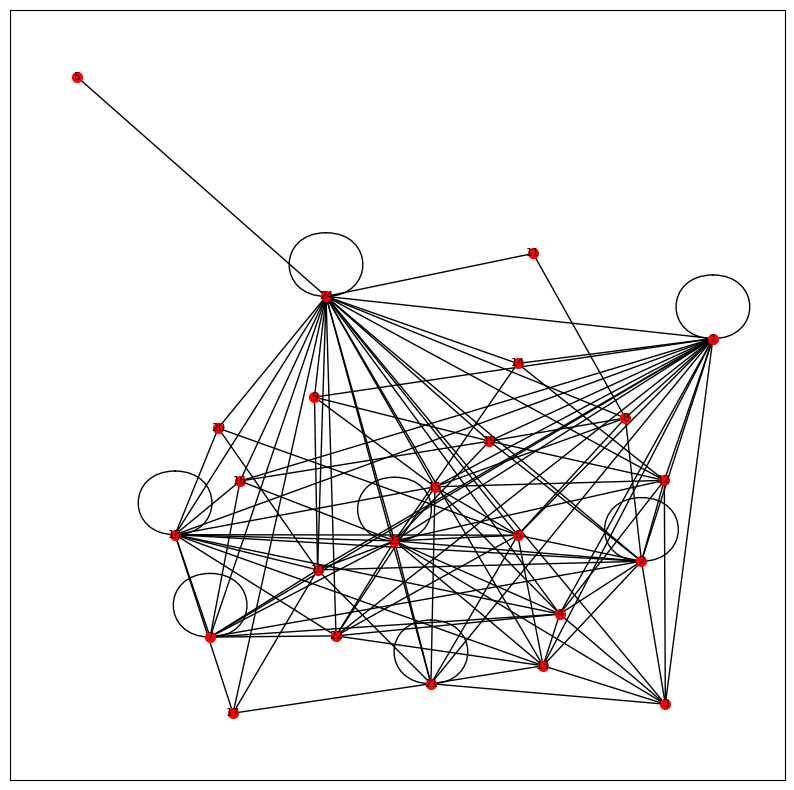

In [4]:

w_opt=4
x =[
0.37,0.73,1.49,1.99,1.92,2.20,2.35,1.94,1.38,0.95,0.90,0.54,-0.11,-0.27,-0.52,-1.16,-1.29,-1.03,-0.67,-0.19,
-0.52,-0.68,-0.73,-0.90,-0.50,-0.24,-0.34,-0.67,-1.19,-1.34,-1.16,-0.72,-0.79,-1.18,-1.03,-0.91,-0.74,-0.56,
-0.70,-0.49,-0.37,-0.41,-0.66,-0.71,-0.42,-0.33,-0.53,-0.31,-0.11,0.32,0.53,0.81,1.01,1.12,1.14,1.13,0.98,0.58,
0.62,0.92,1.29,1.57,1.65,1.24,1.07,0.94,0.90,0.28,0.10,-0.44,-1.25,-1.74,-1.74,-1.19,-1.00,-1.90,-2.05,-1.96,
-1.97,-1.47,-1.21,-1.08,-0.88,-0.59,-0.57,-0.53,-0.30,-0.40,-0.45,-0.13,0.01,0.21,0.04,0.08,0.08,-0.08,0.09,
0.22,0.22,0.21,0.10,0.35,0.49,0.32,0.03,0.19,0.26,0.52,0.76,0.68,0.42,0.86,1.20,1.69,1.84,1.78,1.38,1.20,1.04,
0.58,0.22,0.05,-0.06,-0.30,-0.28,-0.15,0.14,0.41,0.39,0.59,0.78,0.35,0.23,0.13,0.35,0.06,0.00,0.16,0.10,0.06,
0.11,0.26,0.31,0.32,0.24,0.53,0.48,0.75,1.11,1.25,1.02,0.73,0.46,0.28,-0.11,-0.14,-0.21,-0.63,-0.84,-0.88,
-1.10,-0.95,-0.86,-0.86,-0.61,-0.47,-0.38,-0.44,-0.44,-0.22,-0.45,-0.44,-0.41,-0.64,-0.53,-0.37,-0.25,0.16,
0.64,1.09,1.56,1.89,2.13,2.36,2.41,2.29,2.38,2.03,1.34,0.78,0.57,-0.39,-0.99,-1.28,-1.26,-1.46,-1.46,-1.69,
-1.69,-1.32,-0.95,-1.11,-1.15,-1.19,-1.17,-1.22,-1.09,-1.23,-1.58,-1.74,-1.77,-1.55,-0.98,-0.87,-0.86,-0.79,
-0.67,-0.49,-0.52,-0.70,-0.79,-0.92,-0.73,-0.63,-0.48,-0.49,-0.34,-0.19,-0.04,-0.05,-0.20,-0.14,-0.37,-0.41,
-0.15,-0.04,0.01,0.02,0.31,0.72,0.74,0.87,1.09,1.25,1.47,1.37,0.60,0.64,0.36,-0.14,-0.61,-0.29,0.21,0.26,0.27,
0.42,0.33,0.43,0.27,0.23,0.12,0.07,0.06,0.13,0.49,0.76,0.81,0.73,0.66,0.74,0.66,0.36,0.45,0.26,0.30,0.04,-0.23,
-0.05,-0.04,-0.06,-0.59,-0.92,-0.91,-0.67,-0.71,-0.32,-0.09,0.00,0.01,0.31,0.60,0.70,0.99,1.14,0.70,0.13,-0.18,
-0.32,-0.47,-0.35,-0.59,-0.72,-1.11,-1.39,-1.54,-1.58,-1.68,-1.67,-1.21,-0.99,-0.84,-0.68,-0.30,-0.13,-0.25,
-0.35,-0.46,-0.86,-0.89,-0.79,-0.69,-0.35,0.06,0.31,0.48,0.56,0.68,0.89,1.46,1.74,1.52,1.25,0.90,0.38,-0.22,
-0.69,-1.07,-1.39,-1.60,-1.69,-1.64,-1.60,-1.54,-1.11,-0.93,-0.77,-0.52,-0.38,-0.43,-0.65,-0.80,-1.05,-1.19,
-1.06,-0.87,-0.67,-0.61,-0.50,-0.32,0.02,0.25,0.47,0.38,0.26,0.16,-0.25,-0.53,-0.52,-0.25,-0.25,-0.40,-0.42,
-0.39,-0.38,-0.18,-0.20,-0.14,-0.17,-0.49,-0.62,-0.28,0.08,0.32,0.23,-0.06,-0.03,0.29,0.44,0.75,0.71,0.51,0.42,
0.47,0.70,0.92,1.18,1.46,1.93,2.21,2.36,2.72,2.66,2.57,2.26,1.62,0.91,0.30,-0.03,-0.48,-0.58,-0.58,-0.74,-0.76,
-0.50,-0.43,-0.08,0.03,0.22,0.37,0.34,0.25,-0.16,-0.43,-0.56,-0.97,-0.98,-0.98,-0.78,-0.80,-0.51,-0.20,0.04,0.12,
0.09,0.47,0.90,0.90,0.89,0.65,0.71,0.81,0.62,0.55,0.45,0.35
]

nodos = crear_ind(x , w_opt)
print("len() de nodos es",len(nodos))

G, unique_nodes, nodo_a_sublista= crear_grafo(nodos, w_opt)
A = nx.to_numpy_array(G)
print(unique_nodes)
print("len() de unique_nodes es",len(unique_nodes))
# Dibujar el grafo
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G)  # Layout para la visualización
nx.draw_networkx_nodes(G, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G, pos, edge_color="black")
# Etiquetas con índices 1‑based
labels = {i: i+1 for i in G.nodes()}
nx.draw_networkx_labels(G, pos, labels, font_size=8)
#nx.draw_networkx_labels(G, pos, {i: f"{i}" for i in G.nodes()}, font_size=8)
#MU,MUT,MC=calcular_entropia(unique_nodes,nodos)
#for i in range(len(MC)):
 #   print(MC[i])
#plt.title("Grafo")
def calcular_grado_medio(G):
    grados = [grado for _, grado in G.degree()]  # Obtener los grados de todos los nodos
    grado_medio = np.mean(grados)  # Calcular el grado medio
    return grado_medio
#G, unique_nodes = crear_grafo(nodos, w_opt)
grado_medio = calcular_grado_medio(G)
distancia_media=nx.average_shortest_path_length(G)
print(f"El grado medio de la red es: {grado_medio}")
print((f"La distancia minima promedio de la red es: {distancia_media}"))
print("la distancia maxima es:",nx.diameter(G))
print(A)
plt.show()

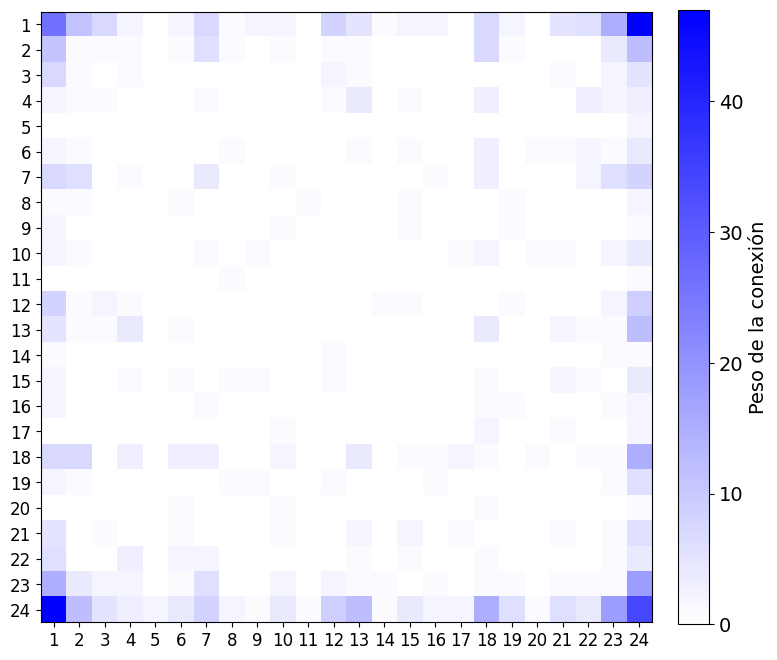

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

C = nx.adjacency_matrix(G).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})

fig, ax = plt.subplots(figsize=(8, 8))
azul_personalizado = LinearSegmentedColormap.from_list(
    'azul_personalizado',
    [(1, 1, 1), (0, 0, 1)]  # Blanco → Azul
)

im = ax.imshow(C, cmap=azul_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Peso de la conexión', fontsize=14)

plt.tight_layout()
plt.savefig("matriz_adyacencia_nino34_tabatinga.png", dpi=300, bbox_inches='tight')
plt.show()

In [6]:
from matplotlib.colors import ListedColormap

A = np.array(A, dtype=int)
#A1 = np.array(A1, dtype=int)
print("NIÑO 3.4")
print(A)

cmap = ListedColormap(['white', 'blue'])
#plt.imshow(A, cmap=cmap, interpolation='nearest')

#plt.imshow(A, cmap='gray_r', interpolation='nearest')

NIÑO 3.4
[[26 11  7  2  0  2  7  1  2  2  0  8  5  1  2  2  0  7  2  0  5  6 15 47]
 [11  1  1  1  0  1  6  1  0  1  0  1  1  0  0  0  0  7  1  0  0  0  4 12]
 [ 7  1  0  1  0  0  0  0  0  0  0  2  1  0  0  0  0  0  0  0  1  0  2  5]
 [ 2  1  1  0  0  0  1  0  0  0  0  1  4  0  1  0  0  3  0  0  0  3  2  3]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2]
 [ 2  1  0  0  0  0  0  1  0  0  0  0  1  0  1  0  0  3  0  1  1  2  1  4]
 [ 7  6  0  1  0  0  4  0  0  1  0  0  0  0  0  1  0  3  0  0  0  2  6  8]
 [ 1  1  0  0  0  1  0  0  0  0  1  0  0  0  1  0  0  0  1  0  0  0  0  2]
 [ 2  0  0  0  0  0  0  0  0  1  0  0  0  0  1  0  0  0  1  0  0  0  0  1]
 [ 2  1  0  0  0  0  1  0  1  0  0  0  0  0  0  0  1  2  0  1  1  0  2  4]
 [ 0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 8  1  2  1  0  0  0  0  0  0  0  0  0  1  1  0  0  0  1  0  0  0  2  9]
 [ 5  1  1  4  0  1  0  0  0  0  0  0  0  0  0  0  0  4  0  0  2  1  1 12]
 [ 1  0  0  0  0

In [7]:
nodos_activos = contar_nodos_activos(G)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 24 de 24 posibles
Porcentaje: 100.00%


#Mapeo anomalias caudal Tabatinga

len() de nodos es 442
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
len() de unique_nodes es 24


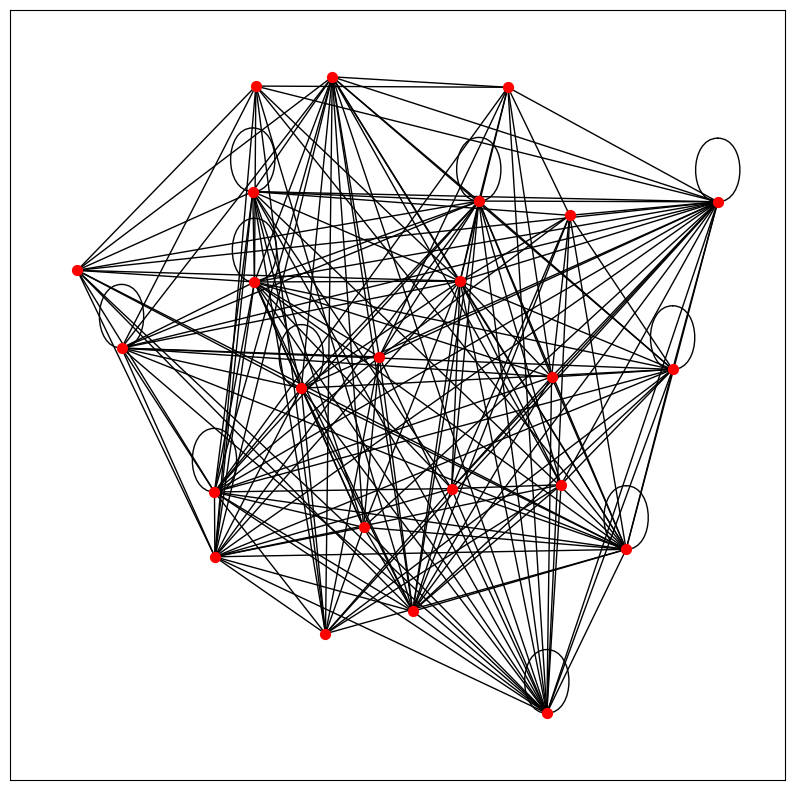

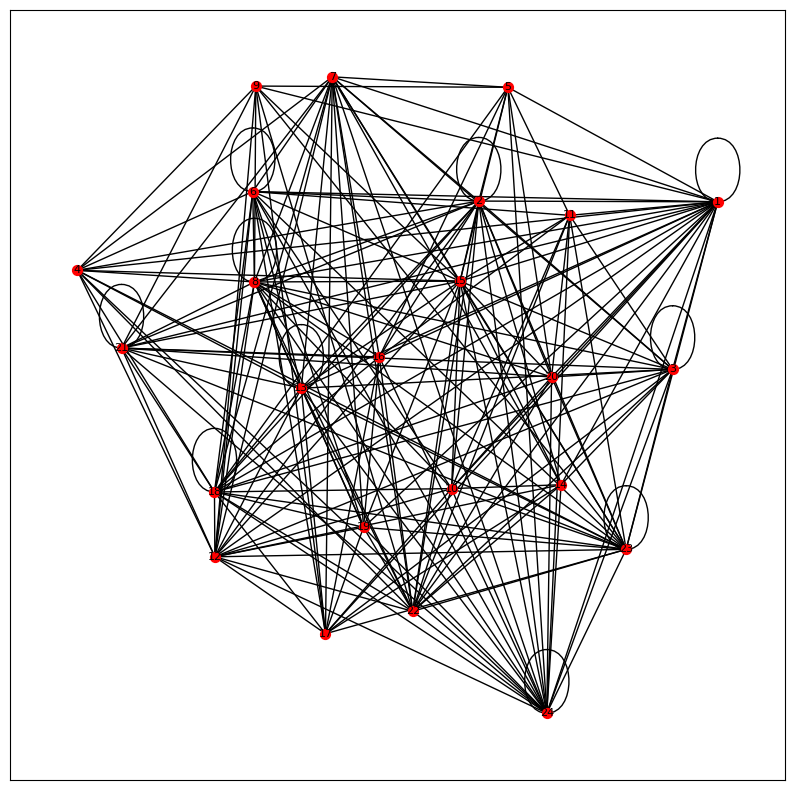

El grado medio de la red es: 16.583333333333332
La distancia minima promedio de la red es: 1.315217391304348
la distancia maxima es: 2
[[ 2.  6.  2.  3.  1.  3.  3.  2.  2.  3.  1.  4.  5.  1.  3.  2.  4.  6.
   4.  2.  2.  2.  7.  8.]
 [ 6.  1.  2.  3.  1.  2.  1.  1.  0.  1.  0.  5.  3.  1.  3.  2.  0.  7.
   0.  1.  2.  4.  3. 11.]
 [ 2.  2.  2.  0.  0.  0.  3.  2.  0.  0.  1.  2.  1.  1.  1.  0.  3.  2.
   0.  1.  3.  2.  1.  5.]
 [ 3.  3.  0.  0.  0.  1.  1.  2.  2.  0.  0.  1.  2.  0.  2.  0.  0.  1.
   0.  0.  0.  2.  3.  3.]
 [ 1.  1.  0.  0.  0.  0.  1.  0.  1.  0.  1.  0.  0.  0.  1.  1.  0.  2.
   0.  1.  0.  0.  0.  2.]
 [ 3.  2.  0.  1.  0.  1.  1.  3.  0.  2.  1.  2.  3.  0.  3.  0.  2.  2.
   1.  0.  0.  0.  2.  7.]
 [ 3.  1.  3.  1.  1.  1.  0.  4.  0.  0.  0.  5.  1.  2.  1.  2.  3.  3.
   2.  0.  2.  4.  2.  6.]
 [ 2.  1.  2.  2.  0.  3.  4.  1.  1.  2.  0.  2.  1.  0.  1.  2.  0.  1.
   3.  2.  1.  1.  4.  3.]
 [ 2.  0.  0.  2.  1.  0.  0.  1.  0.  0.  0.  3.  0.  0.

In [8]:

w_opt=4
x1 =[
    0.02369368285, 1.145659341, 0.7661291032, 0.9676329862, 1.51727918,
    1.969111031, 1.997164118, 0.827221822, -0.3820626764, -0.7351951086,
    -0.3648324663, -0.5641033081, -1.665626067, -1.151435079, -0.02541876756,
    -0.2287155016, 0.2680296318, 0.44875508, -0.3901255173, 0.07126650298,
    0.5834829446, 0.1441981819, 0.258634026, 0.2602848421, 0.6279164195,
    0.432060862, 1.217594509, 0.6683425922, -0.3420483376, 0.7688873613,
    -0.3916011203, -2.052791991, -2.134970109, -2.326249815, -2.076727318,
    -1.208683528, -0.279751737, 0.4630600463, 0.7443441597, 1.609011783,
    -0.0246138361, -0.6388614993, -1.990151415, -1.03293094, -0.9955984352,
    -0.07000954005, 0.588159753, 0.4330957672, -0.2171026234, -0.1079559011,
    1.20445573, 2.174625538, 1.832869721, 0.4835562469, 0.9911569842,
    1.33836752, 1.626802409, 0.6691455824, -0.1669261959, -0.9473277684,
    -0.5726786734, -0.2526644825, 0.09783145777, 0.05475663005, 0.5328770924,
    0.447345088, -0.4758875664, 0.1322765377, -0.4875566911, -1.406865679,
    -0.6440116464, -0.7720502732, -1.521702428, -1.612239325, -1.474498961,
    -0.3327168808, 0.0992730369, -0.9804000232, -0.5040420726, 0.4881334885,
    0.2099869234, 0.2645084792, 0.3088121898, 0.9687441953, 1.881770955,
    1.67436003, 0.6162622543, 2.353652788, 1.024600072, -1.935733714,
    -1.631993043, 0.3670581298, -0.2102339283, -0.5118678526, -1.469425603,
    -1.126682655, 0.9165333431, 0.3122476432, 0.5917647886, -0.8084474255,
    0.5536387294, 1.218674819, 0.5211479012, -0.4914611678, -0.3864204326,
    -0.5528719798, -0.1841012721, -0.0399823201, -0.2553796412, -0.7872632466,
    -0.8686740919, -0.6596522754, -0.04120948668, -0.8947750526, -1.346198244,
    -2.22599596, -1.468354459, -1.216571402, -1.969242772, -1.894490706,
    -0.7802263101, -0.4911250217, 1.701525414, 0.9557323308, -0.330301622,
    0.5477749748, 0.7022929314, 0.4653213885, 0.5101273819, 1.108572019,
    1.129848186, 0.6817159708, 0.06202201032, 1.323081663, 2.3601597,
    1.404187461, 2.460362879, 2.026728433, 0.6905471312, 0.2142778186,
    0.3888365009, 0.3613781964, 1.311477424, 1.926327134, 1.93641576,
    0.4772565753, 0.6693259689, 0.6213313078, 0.08110660459, 0.5565553797,
    -0.3017073826, -0.9025760834, -1.239632783, -1.102813659, -1.635339085,
    -1.030788448, -0.7919249161, -1.177839252, -1.372609848, -1.24936301,
    -0.4143725926, -0.3989705826, -0.2335345218, -0.1593343627, -0.01461909429,
    -0.4451939259, 0.01610623401, -0.1147848353, -1.275775154, -0.01653574042,
    -0.1937646737, 0.9708114221, 0.4083072708, -0.4321694858, -1.589023482,
    -1.098163604, 0.9662997222, 0.5074258453, 0.4170263955, 0.9610424558,
    -1.004449591, -0.7023584012, -0.6316674688, -1.031898861, -0.7987360552,
    0.4647777167, 0.8833199134, 0.2969647766, 0.3208070846, 0.6529330775,
    0.641873962, -0.524738862, -0.7234778092, -1.121121718, -1.172476573,
    -1.725684891, 0.8675901931, -1.052950522, -1.00503882, 1.213922819,
    1.169903776, 0.9256409215, 1.809105612, 2.079002792, 0.9286937362,
    0.1456613188, -1.041512613, -0.5484809361, -1.263482566, -0.7542885741,
    -1.230924134, -1.144934409, -0.6929159522, -0.3628479111, 0.8347287394,
    1.066702267, 1.732818968, 1.808164031, 0.2467658772, 0.4536872935,
    -1.632343096, -1.45704142, -0.5128366668, 0.5501072807, 0.02242183344,
    0.0276708024, 0.223441958, 0.2491097692, 0.1463238069, 0.2174669514,
    0.6963664241, -0.3602879642, -0.4485883166, 0.1013843163, -0.4879284873,
    -0.1006175373, 0.376489525, 0.594838268, 0.4947632601, 0.6359082394,
    0.267825118, 2.101490383, 0.7086575401, -0.4407097841, 1.293750109,
    1.206113072, 0.6970397846, -0.1313834929, -0.1147264382, -0.5462518736,
    -0.07454000158, 0.9978396554, 1.343891629, 0.5745748109, 0.2639734396,
    0.3661694307, -0.04155096097, 0.05581593756, 0.9532634979, -1.878014774,
    -1.668690195, -1.627288195, -1.659305613, -0.6767601243, 0.8151454247,
    0.6215536632, 1.189621624, 0.5767592881, 1.435940004, 1.06530614,
    0.1191936309, -0.6894790332, -0.3715919566, -0.7936952307, -0.764405563,
    -1.256303433, -0.9004448794, -1.285170498, -1.74659884, -1.327641233,
    0.1008438186, -1.489086693, -0.5369775326, 0.3569501048, -0.1384519997,
    0.1807438702, -0.2433159957, -1.700789442, -1.047190551, -1.067901879,
    -0.7050750995, -0.5158095718, -0.2721826975, 0.6028287545, 1.407454116,
    0.6543911663, -1.209491635, -0.7667419412, -0.5384915703, -0.7080201256,
    -0.8474932945, -0.9720924537, -0.7477973234, -0.7696409408, 0.6505491333,
    0.3262780451, 0.7433146962, 0.2721089776, 0.3556691342, -0.2034924976,
    -0.5989972309, -0.9256823569, -0.1978101855, -0.3787872698, -0.002277562942,
    -0.1441543233, 0.03015864028, -0.3615417032, -0.4961918644, 1.047886082,
    1.422048392, 0.9242223273, 1.033140159, 1.077474635, 1.13829376,
    0.8639233915, 0.3248356554, 0.1767198679, -1.153118075, 0.920397414,
    0.2435574558, -0.2383186638, -0.7409117948, -0.764647826, -0.780682596,
    -0.7923868924, -1.042726609, -1.017631078, -1.712861846, -2.303716722,
    -2.030228941, -1.923171967, -1.793542064, -1.365280591, -1.081845693,
    0.08758951869, 0.7342040286, 0.1981172067, 0.4616217617, -0.2387422825,
    -0.9640361988, 0.2457584523, -0.9364867845, -0.0131454908, 1.572662633,
    1.422393453, 1.617300079, 2.500212915, 1.380514495, 0.05284125864,
    -0.4709315873, -0.8656527767, -0.8510426979, -0.5348062701, -1.272224308,
    -0.7255760091, 1.192370216, 1.055232352, 1.437542636, 1.200780641,
    -0.007748038515, -0.2149577863, 0.5039009342, 0.9982760507, 1.437756854,
    0.1689610349, -0.1271244185, -0.091464139, 0.08684841206, 0.05497976449,
    -0.007598264851, 0.4518304637, 0.6068274103, 0.6205377407, 0.4429963496,
    0.4664205773, 0.2966084718, 0.511120891, -0.09372823273, 0.6598693412,
    1.201341882, 1.566488519, 1.514650711, 2.023430164, 2.201382108,
    2.175501057, 1.823637093, 1.569977821, 0.06611674563, -0.3978222966,
    -0.9890055306, -0.5423411358, -0.105865346, -0.996355775, 0.2849766447,
    0.3932627895, -0.5728978504, -0.07851618643, -0.2366259549, -0.5160889665,
    -0.7867050631, 0.02592895565, -1.634118762, -1.331103495, 0.5722627908,
    1.173638013, 0.7859975593, 0.7154863258, 0.211655141, 0.04821014734,
    -0.7548793305, -1.581377306, -0.6001343987, -0.1577550723, 0.4738703348,
    -0.03480809562, -0.299936659, -0.2672618608, -1.487359118, -1.22035432,
    -0.4983602647, 0.07841304714, -1.244578872, 0.1487475208, -0.3029436903,
    -0.7678860937, 0.214418168, 1.187270451, 0.748567843, 1.205913729,
    1.2396884, 0.9190883674, 0.04765000144, 0.06618087272, 0.7772754637
]

nodos1 = crear_ind(x1 , w_opt)
print("len() de nodos es",len(nodos1))

G1, unique_nodes1, nodo_a_sublista1= crear_grafo(nodos1, w_opt)
A1 = nx.to_numpy_array(G1)
print(unique_nodes1)
print("len() de unique_nodes es",len(unique_nodes1))
# Dibujar el grafo
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G1)  # Layout para la visualización
nx.draw_networkx_nodes(G1, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G1, pos, edge_color="black")
plt.figure(figsize=(10, 10))
pos = nx.kamada_kawai_layout(G1)
nx.draw_networkx_nodes(G1, pos, node_size=50, node_color="red")
nx.draw_networkx_edges(G1, pos, edge_color="black")
labels = {i: i+1 for i in G1.nodes()}
nx.draw_networkx_labels(G1, pos, labels, font_size=8)
plt.show()
#nx.draw_networkx_labels(G, pos, {i: f"{i}" for i in G.nodes()}, font_size=8)
#MU,MUT,MC=calcular_entropia(unique_nodes,nodos)
#for i in range(len(MC)):
 #   print(MC[i])
#plt.title("Grafo")
def calcular_grado_medio(G1):
    grados = [grado for _, grado in G1.degree()]  # Obtener los grados de todos los nodos
    grado_medio = np.mean(grados)  # Calcular el grado medio
    return grado_medio
#G, unique_nodes = crear_grafo(nodos, w_opt)
grado_medio = calcular_grado_medio(G1)
distancia_media=nx.average_shortest_path_length(G1)
print(f"El grado medio de la red es: {grado_medio}")
print((f"La distancia minima promedio de la red es: {distancia_media}"))
print("la distancia maxima es:",nx.diameter(G1))
print(A1)
plt.show()

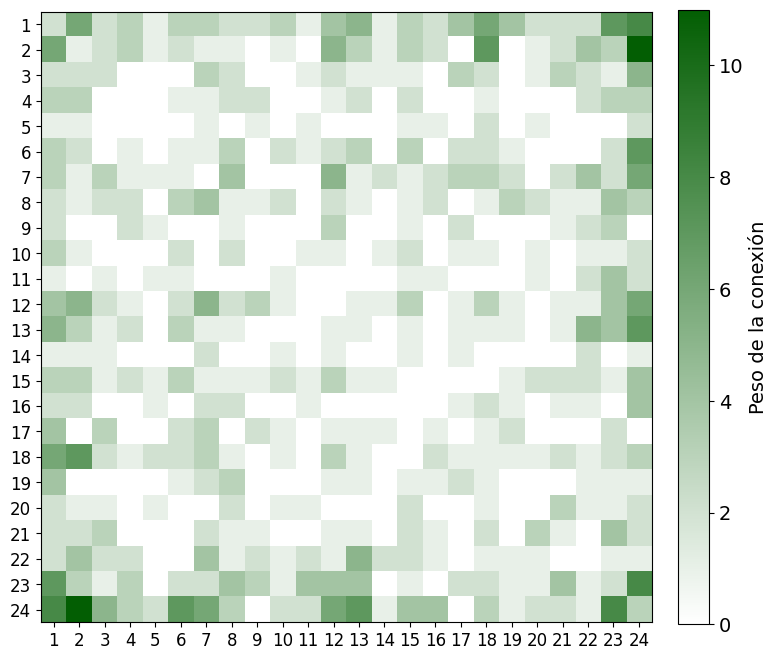

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap,to_rgb

C = nx.adjacency_matrix(G1).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})
fig, ax = plt.subplots(figsize=(8, 8))
# Blanco → Verde
color_hex = '#035e03'  # Cambia este valor por el hexadecimal que desees
verde_personalizado = LinearSegmentedColormap.from_list(
    'verde_personalizado',                # nombre del mapa
    [(1, 1, 1), to_rgb(color_hex)]        # blanco → color hexadecimal
)


im = ax.imshow(C, cmap=verde_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Peso de la conexión', fontsize=14)

plt.tight_layout()
plt.savefig("matriz_adyacencia_tabatinga.png", dpi=300, bbox_inches='tight')

plt.show()

In [10]:
print(unique_nodes)
print(nodo_a_sublista)
print(unique_nodes1)
print(nodo_a_sublista1)

{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, (2, 3, 4, 1): 9, (2, 4, 1, 3): 10, (2, 4, 3, 1): 11, (3, 1, 2, 4): 12, (3, 1, 4, 2): 13, (3, 2, 1, 4): 14, (3, 2, 4, 1): 15, (3, 4, 1, 2): 16, (3, 4, 2, 1): 17, (4, 1, 2, 3): 18, (4, 1, 3, 2): 19, (4, 2, 1, 3): 20, (4, 2, 3, 1): 21, (4, 3, 1, 2): 22, (4, 3, 2, 1): 23}
{0: (1, 2, 3, 4), 1: (1, 2, 4, 3), 2: (1, 3, 2, 4), 3: (1, 3, 4, 2), 4: (1, 4, 2, 3), 5: (1, 4, 3, 2), 6: (2, 1, 3, 4), 7: (2, 1, 4, 3), 8: (2, 3, 1, 4), 9: (2, 3, 4, 1), 10: (2, 4, 1, 3), 11: (2, 4, 3, 1), 12: (3, 1, 2, 4), 13: (3, 1, 4, 2), 14: (3, 2, 1, 4), 15: (3, 2, 4, 1), 16: (3, 4, 1, 2), 17: (3, 4, 2, 1), 18: (4, 1, 2, 3), 19: (4, 1, 3, 2), 20: (4, 2, 1, 3), 21: (4, 2, 3, 1), 22: (4, 3, 1, 2), 23: (4, 3, 2, 1)}
{(1, 2, 3, 4): 0, (1, 2, 4, 3): 1, (1, 3, 2, 4): 2, (1, 3, 4, 2): 3, (1, 4, 2, 3): 4, (1, 4, 3, 2): 5, (2, 1, 3, 4): 6, (2, 1, 4, 3): 7, (2, 3, 1, 4): 8, 

In [11]:
nodos_activos = contar_nodos_activos(G1)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 24 de 24 posibles
Porcentaje: 100.00%


## W OPTIMO

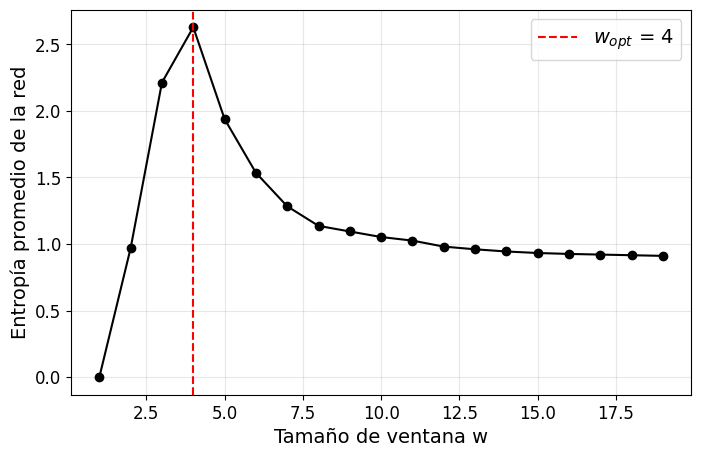

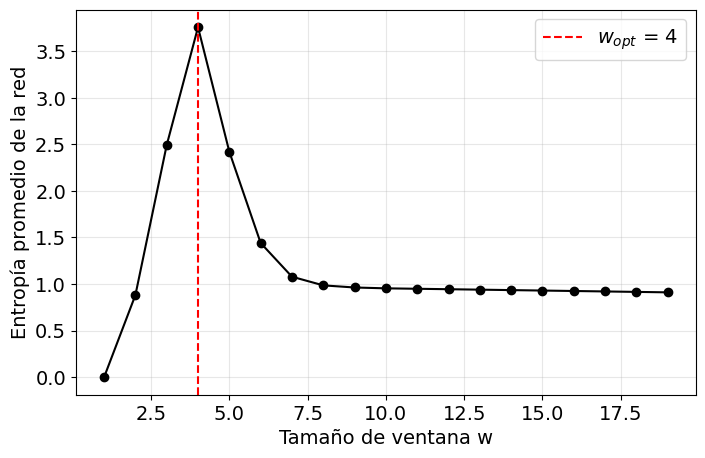

4
4


In [12]:
ventana=optimizar_w(x,1,20)
ventana1=optimizar_w(x1,1,20)
print(ventana)
print(ventana1)

##INTERSECCIÓN

NIÑO 3.4
[[26 11  7  2  0  2  7  1  2  2  0  8  5  1  2  2  0  7  2  0  5  6 15 47]
 [11  1  1  1  0  1  6  1  0  1  0  1  1  0  0  0  0  7  1  0  0  0  4 12]
 [ 7  1  0  1  0  0  0  0  0  0  0  2  1  0  0  0  0  0  0  0  1  0  2  5]
 [ 2  1  1  0  0  0  1  0  0  0  0  1  4  0  1  0  0  3  0  0  0  3  2  3]
 [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  2]
 [ 2  1  0  0  0  0  0  1  0  0  0  0  1  0  1  0  0  3  0  1  1  2  1  4]
 [ 7  6  0  1  0  0  4  0  0  1  0  0  0  0  0  1  0  3  0  0  0  2  6  8]
 [ 1  1  0  0  0  1  0  0  0  0  1  0  0  0  1  0  0  0  1  0  0  0  0  2]
 [ 2  0  0  0  0  0  0  0  0  1  0  0  0  0  1  0  0  0  1  0  0  0  0  1]
 [ 2  1  0  0  0  0  1  0  1  0  0  0  0  0  0  0  1  2  0  1  1  0  2  4]
 [ 0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1]
 [ 8  1  2  1  0  0  0  0  0  0  0  0  0  1  1  0  0  0  1  0  0  0  2  9]
 [ 5  1  1  4  0  1  0  0  0  0  0  0  0  0  0  0  0  4  0  0  2  1  1 12]
 [ 1  0  0  0  0

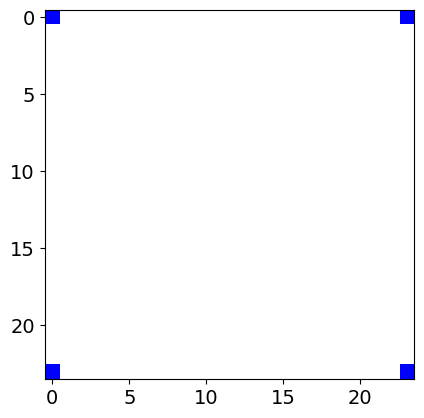

In [13]:
from matplotlib.colors import ListedColormap

A = np.array(A, dtype=int)
A1 = np.array(A1, dtype=int)
print("NIÑO 3.4")
print(A)


# contar diagonal (loops)
loops = np.count_nonzero(np.diag(A))

# contar fuera de la diagonal
off_diag = np.count_nonzero(A) - loops

# calcular M
M = off_diag / 2 + loops

print("M =", M)

cmap = ListedColormap(['white', 'blue'])
plt.imshow(A, cmap=cmap, interpolation='nearest')

#plt.imshow(A, cmap='gray_r', interpolation='nearest')



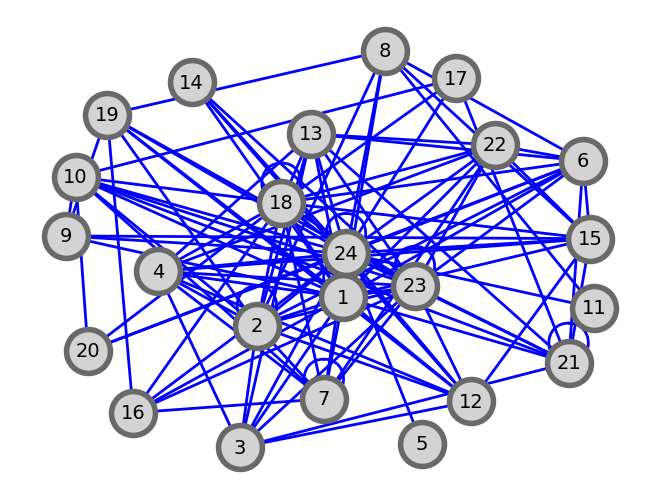

In [14]:
G = nx.from_numpy_array(A)
pos = nx.spring_layout(G, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in G.nodes()}

nx.draw(
    G, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='blue',
    width=2,
    font_size=14
)
plt.savefig("grafo_nino34_tabatinga.png", dpi=300, bbox_inches='tight')

plt.show()

CALAMAR
[[ 2  6  2  3  1  3  3  2  2  3  1  4  5  1  3  2  4  6  4  2  2  2  7  8]
 [ 6  1  2  3  1  2  1  1  0  1  0  5  3  1  3  2  0  7  0  1  2  4  3 11]
 [ 2  2  2  0  0  0  3  2  0  0  1  2  1  1  1  0  3  2  0  1  3  2  1  5]
 [ 3  3  0  0  0  1  1  2  2  0  0  1  2  0  2  0  0  1  0  0  0  2  3  3]
 [ 1  1  0  0  0  0  1  0  1  0  1  0  0  0  1  1  0  2  0  1  0  0  0  2]
 [ 3  2  0  1  0  1  1  3  0  2  1  2  3  0  3  0  2  2  1  0  0  0  2  7]
 [ 3  1  3  1  1  1  0  4  0  0  0  5  1  2  1  2  3  3  2  0  2  4  2  6]
 [ 2  1  2  2  0  3  4  1  1  2  0  2  1  0  1  2  0  1  3  2  1  1  4  3]
 [ 2  0  0  2  1  0  0  1  0  0  0  3  0  0  1  0  2  0  0  0  1  2  3  0]
 [ 3  1  0  0  0  2  0  2  0  0  1  1  0  1  2  0  1  1  0  1  0  1  1  2]
 [ 1  0  1  0  1  1  0  0  0  1  0  0  0  0  1  1  0  0  0  1  0  2  4  2]
 [ 4  5  2  1  0  2  5  2  3  1  0  0  1  1  3  0  1  3  1  0  1  1  4  6]
 [ 5  3  1  2  0  3  1  1  0  0  0  1  1  0  1  0  1  1  1  0  1  5  4  7]
 [ 1  1  1  0  0 

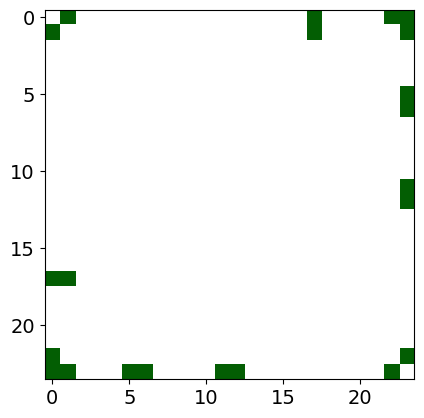

In [15]:
print("CALAMAR")
print(A1)

# contar diagonal (loops)
loops = np.count_nonzero(np.diag(A1))

# contar fuera de la diagonal
off_diag = np.count_nonzero(A1) - loops

# calcular M
M = off_diag / 2 + loops

print("M =", M)

cmap = ListedColormap(['white', '#035e03'])
plt.imshow(A1, cmap=cmap, interpolation='nearest')


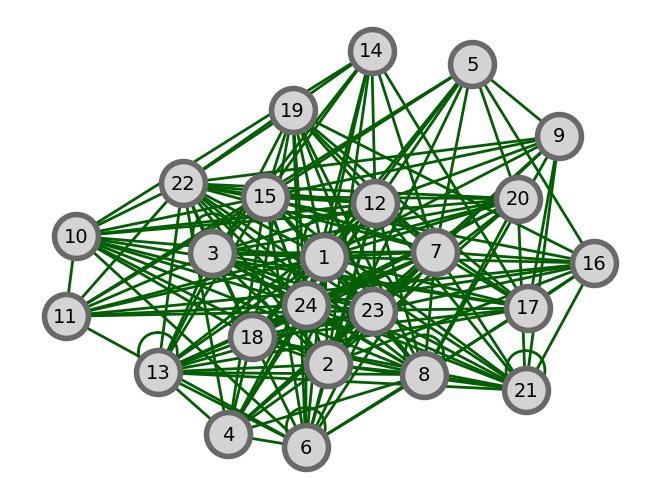

In [16]:
G1 = nx.from_numpy_array(A1)
pos = nx.spring_layout(G1, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in G1.nodes()}

nx.draw(
    G1, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='#035e03',
    width=2,
    font_size=14
)
plt.savefig("grafo_ordinal_tabatinga.png", dpi=300, bbox_inches='tight')

plt.show()

In [17]:
print(A.shape, A1.shape)

(24, 24) (24, 24)


##INTERSECCIÓN


In [18]:
C = np.divide(A1 ,A, out=np.zeros_like(A, dtype=float), where=A!=0) * 100
C_clean = np.where(np.isinf(C), 0, C)
#print(C_clean)
C_clean_beauty = np.array(C_clean, dtype=int)
print(C_clean_beauty)

[[  7  54  28 150   0 150  42 200 100 150   0  50 100 100 150 100   0  85
  200   0  40  33  46  17]
 [ 54 100 200 300   0 200  16 100   0 100   0 500 300   0   0   0   0 100
    0   0   0   0  75  91]
 [ 28 200   0   0   0   0   0   0   0   0   0 100 100   0   0   0   0   0
    0   0 300   0  50 100]
 [150 300   0   0   0   0 100   0   0   0   0 100  50   0 200   0   0  33
    0   0   0  66 150 100]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0 100]
 [150 200   0   0   0   0   0 300   0   0   0   0 300   0 300   0   0  66
    0   0   0   0 200 175]
 [ 42  16   0 100   0   0   0   0   0   0   0   0   0   0   0 200   0 100
    0   0   0 200  33  75]
 [200 100   0   0   0 300   0   0   0   0   0   0   0   0 100   0   0   0
  300   0   0   0   0 150]
 [100   0   0   0   0   0   0   0   0   0   0   0   0   0 100   0   0   0
    0   0   0   0   0   0]
 [150 100   0   0   0   0   0   0   0   0   0   0   0   0   0   0 100  50
    0 100   0   0

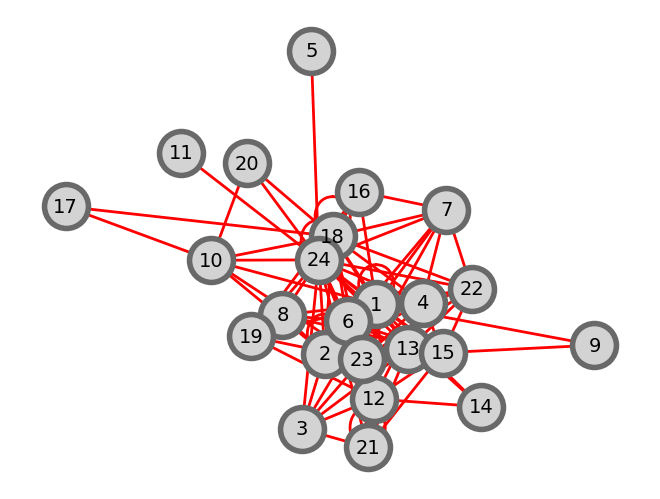

In [19]:
GC = nx.from_numpy_array(C_clean)
pos = nx.spring_layout(GC, k=5, iterations=100)

# Crear un diccionario de etiquetas con índices 1‑based
labels = {i: i+1 for i in GC.nodes()}

nx.draw(
    GC, pos,
    labels=labels,                # Usar las etiquetas personalizadas
    node_color='lightgray',
    edgecolors="dimgray",
    node_size=1000,
    linewidths=4,
    edge_color='red',
    width=2,
    font_size=14
)
plt.savefig("grafo_influencia_tabatinga.png", dpi=300, bbox_inches='tight')

plt.show()

INTERCEPCIÓN
M = 101.0


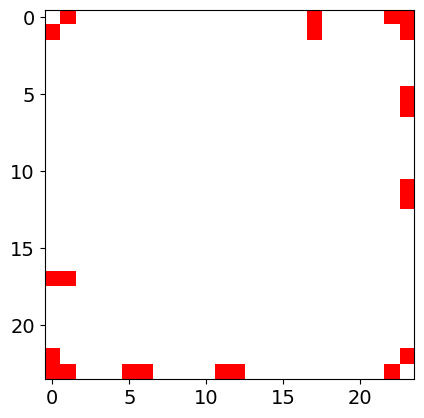

In [20]:
print("INTERCEPCIÓN")
#print(C_clean)

# contar diagonal (loops)
loops = np.count_nonzero(np.diag(C_clean))

# contar fuera de la diagonal
off_diag = np.count_nonzero(C_clean) - loops

# calcular M
M = off_diag / 2 + loops

print("M =", M)

cmap = ListedColormap(['white', 'red'])
plt.imshow(A1, cmap=cmap, interpolation='nearest')

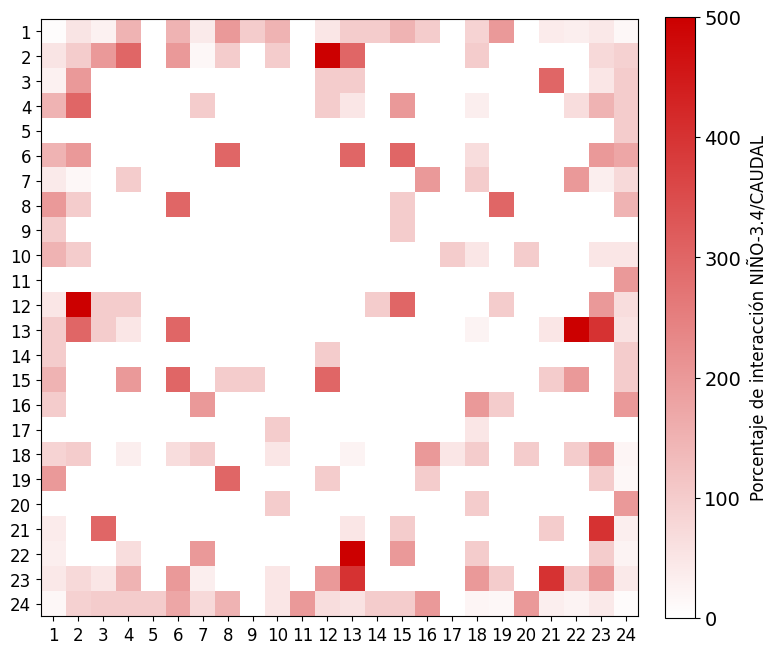

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

C = nx.adjacency_matrix(GC).toarray()
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})

fig, ax = plt.subplots(figsize=(8, 8))
# Blanco → Rojo
rojo_personalizado = LinearSegmentedColormap.from_list(
    'rojo_personalizado',
    [(1, 1, 1), (0.8, 0, 0)]  # Blanco → Rojo
)

im = ax.imshow(C, cmap=rojo_personalizado, interpolation='nearest')
plt.xticks(ticks=range(24), labels=range(1, 25))
plt.yticks(ticks=range(24), labels=range(1, 25))

# Mantener proporción cuadrada
ax.set_aspect('equal')

# Barra de color a la derecha
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,   # ancho de la barra
    pad=0.04          # separación con la figura
)

cbar.ax.tick_params(labelsize=14)
cbar.set_label('Porcentaje de interacción NIÑO-3.4/CAUDAL', fontsize=12)

plt.tight_layout()
plt.savefig("matriz_influencia_tabatinga.png", dpi=300, bbox_inches='tight')

plt.show()



In [22]:
nodos_activos = contar_nodos_activos(GC)
print(f"Nodos activos: {nodos_activos} de {NUM_NODOS_GLOBAL} posibles")
print(f"Porcentaje: {100*nodos_activos/NUM_NODOS_GLOBAL:.2f}%")

Nodos activos: 24 de 24 posibles
Porcentaje: 100.00%


#PORCENTAJE DE INTERACCIÓN

In [23]:
upper = np.triu(C_clean)
promedio = np.mean(upper)
print("La influencia del NIÑO 3.4 en el caudal es:",promedio,"%")

La influencia del NIÑO 3.4 en el caudal es: 22.895838894385253 %


##MÉTRICAS

In [24]:
import networkx as nx
import numpy as np

# Intento de importar correctamente python-louvain
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def calcular_metricas_red(G, nombre_grafo):
    """
    Calcula e imprime métricas de red considerando solo nodos activos.
    Las etiquetas en pantalla se muestran como 1‑based.
    """
    print(f"\n=== Métricas para {nombre_grafo} ===")

    # Identificar nodos activos (grado > 0)
    nodos_activos = [n for n in G.nodes() if G.degree(n) > 0]
    num_activos = len(nodos_activos)
    print(f"Nodos activos: {num_activos} de {G.number_of_nodes()}")

    if num_activos == 0:
        print("No hay nodos activos. No se pueden calcular métricas.")
        return

    # Subgrafo inducido por los nodos activos
    G_activo = G.subgraph(nodos_activos).copy()

    # ---- Grado medio (solo activos) ----
    grados = [d for n, d in G_activo.degree()]
    grado_medio = np.mean(grados)
    print(f"Grado medio (solo activos): {grado_medio:.4f}")

    # ---- Coeficiente de clustering promedio (solo activos) ----
    clustering = nx.average_clustering(G, nodes=nodos_activos)
    print(f"Coeficiente de clustering promedio (solo activos): {clustering:.4f}")

    # ---- Diámetro y distancia promedio ----
    if nx.is_connected(G_activo):
        diametro = nx.diameter(G_activo)
        dist_prom = nx.average_shortest_path_length(G_activo)
        print(f"Diámetro (componente activa): {diametro}")
        print(f"Distancia promedio (componente activa): {dist_prom:.4f}")
    else:
        componentes = list(nx.connected_components(G_activo))
        comp_gigante = max(componentes, key=len)
        G_gigante = G_activo.subgraph(comp_gigante)
        diametro = nx.diameter(G_gigante)
        dist_prom = nx.average_shortest_path_length(G_gigante)
        print(f"El grafo activo no es conexo. Métricas sobre la componente gigante ({len(comp_gigante)} nodos):")
        print(f"  Diámetro: {diametro}")
        print(f"  Distancia promedio: {dist_prom:.4f}")

    # ---- Modularidad (sobre grafo activo) ----
    # (Requiere python-louvain instalado)
    particion = community_louvain.best_partition(G_activo)
    modularidad = community_louvain.modularity(particion, G_activo)
    print(f"Modularidad (sobre grafo activo): {modularidad:.4f}")

    # ---- Centralidades ----
    # Centralidad de grado (solo activos)
    cent_grado = nx.degree_centrality(G_activo)
    prom_cent_grado = np.mean(list(cent_grado.values()))
    print(f"Centralidad de grado promedio (activos): {prom_cent_grado:.4f}")

    # Top 3 nodos con mayor centralidad de grado (etiquetas 1‑based)
    top_nodos = sorted(cent_grado.items(), key=lambda x: x[1], reverse=True)[:3]
    print("Top 3 nodos activos con mayor centralidad de grado:")
    for nodo, valor in top_nodos:
        print(f"  Nodo {nodo+1}: {valor:.4f}")

    # Centralidad de cercanía (sobre la componente usada)
    if nx.is_connected(G_activo):
        cent_cercania = nx.closeness_centrality(G_activo)
    else:
        cent_cercania = nx.closeness_centrality(G_gigante)
    prom_cent_cercania = np.mean(list(cent_cercania.values()))
    print(f"Centralidad de cercanía promedio (componente usada): {prom_cent_cercania:.4f}")

    # Centralidad de intermediación (betweenness) sobre todo el grafo activo
    cent_inter = nx.betweenness_centrality(G_activo)
    prom_cent_inter = np.mean(list(cent_inter.values()))
    print(f"Centralidad de intermediación promedio (activos): {prom_cent_inter:.4f}")

In [25]:
calcular_metricas_red(G, "NIÑO 3.4")
calcular_metricas_red(G1, "TABATINGA")
calcular_metricas_red(GC, "INTERSECCIÓN")


=== Métricas para NIÑO 3.4 ===
Nodos activos: 24 de 24
Grado medio (solo activos): 9.8333
Coeficiente de clustering promedio (solo activos): 0.6720
Diámetro (componente activa): 2
Distancia promedio (componente activa): 1.5978
Modularidad (sobre grafo activo): 0.1077
Centralidad de grado promedio (activos): 0.4275
Top 3 nodos activos con mayor centralidad de grado:
  Nodo 24: 1.0870
  Nodo 1: 0.9130
  Nodo 23: 0.7826
Centralidad de cercanía promedio (componente usada): 0.6402
Centralidad de intermediación promedio (activos): 0.0272

=== Métricas para TABATINGA ===
Nodos activos: 24 de 24
Grado medio (solo activos): 16.5833
Coeficiente de clustering promedio (solo activos): 0.7509
Diámetro (componente activa): 2
Distancia promedio (componente activa): 1.3152
Modularidad (sobre grafo activo): 0.0851
Centralidad de grado promedio (activos): 0.7210
Top 3 nodos activos con mayor centralidad de grado:
  Nodo 1: 1.0870
  Nodo 24: 1.0000
  Nodo 23: 0.9565
Centralidad de cercanía promedio (com

##MÉTRICAS PESADAS

In [26]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def calcular_metricas_red_pesada(G, nombre_grafo, usar_inverso_para_distancias=True):
    """
    Calcula e imprime métricas de red considerando pesos en las aristas.

    Parámetros:
    - G: grafo de NetworkX con aristas que tienen atributo 'weight'
    - nombre_grafo: título para la salida
    - usar_inverso_para_distancias: si True, usa 1/weight como distancia para caminos;
      si False, ignora los pesos para distancias (trata como no pesado).
    """
    print(f"\n=== Métricas PESADAS para {nombre_grafo} ===")

    # Nodos activos (grado no pesado > 0, pero usaremos fuerza > 0 para activos pesados)
    # Consideramos nodos activos aquellos con fuerza > 0
    fuerzas = dict(G.degree(weight='weight'))
    nodos_activos = [n for n, f in fuerzas.items() if f > 0]
    num_activos = len(nodos_activos)
    print(f"Nodos con fuerza > 0: {num_activos} de {G.number_of_nodes()}")

    if num_activos == 0:
        print("No hay nodos con fuerza positiva. No se pueden calcular métricas.")
        return

    # ---- Grado medio pesado (fuerza promedio) ----
    fuerza_promedio = np.mean(list(fuerzas.values()))
    print(f"Fuerza promedio (grado pesado): {fuerza_promedio:.4f}")

    # ---- Coeficiente de clustering pesado ----
    # Utiliza la definición estándar de clustering pesado de NetworkX
    clustering_pesado = nx.average_clustering(G, weight='weight')
    print(f"Coeficiente de clustering pesado promedio: {clustering_pesado:.4f}")

    # ---- Preparar grafo con distancias (inverso del peso) si se requiere ----
    if usar_inverso_para_distancias:
        # Crear una copia del grafo con atributo 'distance' = 1/weight
        G_dist = nx.Graph()
        for u, v, data in G.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
    else:
        G_dist = G  # usa el grafo original sin considerar pesos para distancias

    # ---- Diámetro y distancia promedio pesados ----
    # Se calculan sobre el subgrafo de nodos activos (para evitar aislados)
    G_activo = G.subgraph(nodos_activos).copy()
    if usar_inverso_para_distancias:
        G_dist_activo = G_dist.subgraph(nodos_activos).copy()
    else:
        G_dist_activo = G_activo

    if nx.is_connected(G_dist_activo):
        diametro = nx.diameter(G_dist_activo, weight='distance' if usar_inverso_para_distancias else None)
        dist_prom = nx.average_shortest_path_length(G_dist_activo, weight='distance' if usar_inverso_para_distancias else None)
        print(f"Diámetro (pesado): {diametro}")
        print(f"Distancia promedio (pesada): {dist_prom:.4f}")
    else:
        componentes = list(nx.connected_components(G_dist_activo))
        comp_gigante = max(componentes, key=len)
        G_gigante = G_dist_activo.subgraph(comp_gigante)
        diametro = nx.diameter(G_gigante, weight='distance' if usar_inverso_para_distancias else None)
        dist_prom = nx.average_shortest_path_length(G_gigante, weight='distance' if usar_inverso_para_distancias else None)
        print(f"El grafo activo no es conexo. Métricas sobre la componente gigante ({len(comp_gigante)} nodos):")
        print(f"  Diámetro (pesado): {diametro}")
        print(f"  Distancia promedio (pesada): {dist_prom:.4f}")

    # ---- Modularidad pesada ----
    # La partición de Louvain puede usar pesos
    particion = community_louvain.best_partition(G, weight='weight')
    modularidad = community_louvain.modularity(particion, G, weight='weight')
    print(f"Modularidad (pesada): {modularidad:.4f}")

    # ---- Centralidades pesadas ----
    # Centralidad de grado pesada (fuerza normalizada)
    # Normalizamos por la suma total de fuerzas de la red (o por el máximo posible)
    total_fuerza = sum(fuerzas.values())
    cent_fuerza = {n: f / total_fuerza for n, f in fuerzas.items()}
    prom_cent_fuerza = np.mean(list(cent_fuerza.values()))
    print(f"Centralidad de fuerza promedio: {prom_cent_fuerza:.6f}")

    # Top 3 nodos con mayor fuerza (etiquetas 1‑based)
    top_nodos = sorted(fuerzas.items(), key=lambda x: x[1], reverse=True)[:3]
    print("Top 3 nodos con mayor fuerza:")
    for nodo, valor in top_nodos:
        print(f"  Nodo {nodo+1}: {valor:.2f}")

    # Centralidad de cercanía pesada (usando distancias inversas)
    if usar_inverso_para_distancias:
        # Usar el grafo con distancias (G_dist)
        cent_cercania = nx.closeness_centrality(G_dist, distance='distance')
        prom_cent_cercania = np.mean(list(cent_cercania.values()))
        print(f"Centralidad de cercanía promedio (pesada, con inverso): {prom_cent_cercania:.6f}")
    else:
        # Versión no pesada (longitudes de camino = 1 por arista)
        cent_cercania = nx.closeness_centrality(G)
        prom_cent_cercania = np.mean(list(cent_cercania.values()))
        print(f"Centralidad de cercanía promedio (no pesada): {prom_cent_cercania:.6f}")

    # Centralidad de intermediación pesada (usando distancias inversas)
    if usar_inverso_para_distancias:
        cent_inter = nx.betweenness_centrality(G_dist, weight='distance')
    else:
        cent_inter = nx.betweenness_centrality(G, weight=None)
    prom_cent_inter = np.mean(list(cent_inter.values()))
    print(f"Centralidad de intermediación promedio: {prom_cent_inter:.6f}")

In [27]:
# Para NIÑO 3.4 (G)
calcular_metricas_red_pesada(G, "NIÑO 3.4")

# Para CAUDAL (G1)
calcular_metricas_red_pesada(G1, "TABATINGA")

# Para INTERSECCIÓN (GC, si existe)
calcular_metricas_red_pesada(GC, "INTERSECCIÓN")


=== Métricas PESADAS para NIÑO 3.4 ===
Nodos con fuerza > 0: 24 de 24
Fuerza promedio (grado pesado): 36.5000
Coeficiente de clustering pesado promedio: 0.0394
Diámetro (pesado): 2.0
Distancia promedio (pesada): 0.6445
Modularidad (pesada): 0.1105
Centralidad de fuerza promedio: 0.041667
Top 3 nodos con mayor fuerza:
  Nodo 24: 237.00
  Nodo 1: 186.00
  Nodo 23: 61.00
Centralidad de cercanía promedio (pesada, con inverso): 1.810951
Centralidad de intermediación promedio: 0.046154

=== Métricas PESADAS para TABATINGA ===
Nodos con fuerza > 0: 24 de 24
Fuerza promedio (grado pesado): 36.5000
Coeficiente de clustering pesado promedio: 0.1407
Diámetro (pesado): 1.1666666666666665
Distancia promedio (pesada): 0.5111
Modularidad (pesada): 0.0833
Centralidad de fuerza promedio: 0.041667
Top 3 nodos con mayor fuerza:
  Nodo 24: 94.00
  Nodo 1: 80.00
  Nodo 23: 62.00
Centralidad de cercanía promedio (pesada, con inverso): 2.087484
Centralidad de intermediación promedio: 0.041584

=== Métricas 

In [28]:
import networkx as nx
import numpy as np
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def metricas_formateadas(G_nino, G_caudal, G_interseccion=None, decimales=2):
    """
    Calcula las métricas no pesadas y pesadas para los tres grafos.
    Retorna un diccionario con las siguientes claves:
        'grado_medio', 'clustering', 'diametro', 'distancia_promedio',
        'modularidad', 'cent_grado_prom', 'cent_cercania_prom', 'cent_inter_prom'
    Cada valor es una cadena con el formato:
        "(a,b),(c,d),(e,f)" donde a,b son los valores del primer grafo, etc.
    Si un valor es None, se escribe como "None".
    """
    # ------------------------------------------------------------------------
    # Función auxiliar para métricas no pesadas de un grafo
    # ------------------------------------------------------------------------
    def _no_pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        grados = [d for n, d in G.degree()]
        grado_medio = float(np.mean(grados))
        clustering = float(nx.average_clustering(G))
        if nx.is_connected(G):
            diametro = float(nx.diameter(G))
            dist_prom = float(nx.average_shortest_path_length(G))
        else:
            comps = list(nx.connected_components(G))
            if comps:
                G_gig = G.subgraph(max(comps, key=len)).copy()
                diametro = float(nx.diameter(G_gig))
                dist_prom = float(nx.average_shortest_path_length(G_gig))
            else:
                diametro = dist_prom = None
        try:
            particion = community_louvain.best_partition(G)
            modularidad = float(community_louvain.modularity(particion, G))
        except:
            modularidad = None
        cent_grado = nx.degree_centrality(G)
        prom_cent_grado = float(np.mean(list(cent_grado.values())))
        if nx.is_connected(G):
            cent_cercania = nx.closeness_centrality(G)
            prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
        else:
            prom_cent_cercania = None
        cent_inter = nx.betweenness_centrality(G)
        prom_cent_inter = float(np.mean(list(cent_inter.values())))
        return {
            'grado_medio': grado_medio,
            'clustering': clustering,
            'diametro': diametro,
            'distancia_promedio': dist_prom,
            'modularidad': modularidad,
            'cent_grado_prom': prom_cent_grado,
            'cent_cercania_prom': prom_cent_cercania,
            'cent_inter_prom': prom_cent_inter
        }

    # ------------------------------------------------------------------------
    # Función auxiliar para métricas pesadas de un grafo
    # ------------------------------------------------------------------------
    def _pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        fuerzas = dict(G.degree(weight='weight'))
        fuerza_media = float(np.mean(list(fuerzas.values())))
        clustering_pesado = float(nx.average_clustering(G, weight='weight'))
        G_dist = nx.Graph()
        for u, v, data in G.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
        nodos_activos = [n for n, f in fuerzas.items() if f > 0]
        if not nodos_activos:
            diam_pesado = dist_prom_pesado = None
        else:
            G_activo = G.subgraph(nodos_activos).copy()
            G_dist_activo = G_dist.subgraph(nodos_activos).copy()
            if nx.is_connected(G_dist_activo):
                diam_pesado = float(nx.diameter(G_dist_activo, weight='distance'))
                dist_prom_pesado = float(nx.average_shortest_path_length(G_dist_activo, weight='distance'))
            else:
                comps = list(nx.connected_components(G_dist_activo))
                if comps:
                    G_gig = G_dist_activo.subgraph(max(comps, key=len)).copy()
                    diam_pesado = float(nx.diameter(G_gig, weight='distance'))
                    dist_prom_pesado = float(nx.average_shortest_path_length(G_gig, weight='distance'))
                else:
                    diam_pesado = dist_prom_pesado = None
        try:
            particion_pesada = community_louvain.best_partition(G, weight='weight')
            modularidad_pesada = float(community_louvain.modularity(particion_pesada, G, weight='weight'))
        except:
            modularidad_pesada = None
        total_fuerza = sum(fuerzas.values())
        if total_fuerza > 0:
            cent_fuerza_prom = float(np.mean([f/total_fuerza for f in fuerzas.values()]))
        else:
            cent_fuerza_prom = 0.0
        if nodos_activos:
            cent_cercania_pesada = nx.closeness_centrality(G_dist, distance='distance')
            prom_cent_cercania_pesada = float(np.mean(list(cent_cercania_pesada.values())))
        else:
            prom_cent_cercania_pesada = None
        cent_inter_pesada = nx.betweenness_centrality(G_dist, weight='distance')
        prom_cent_inter_pesada = float(np.mean(list(cent_inter_pesada.values())))
        return {
            'grado_medio': fuerza_media,
            'clustering': clustering_pesado,
            'diametro': diam_pesado,
            'distancia_promedio': dist_prom_pesado,
            'modularidad': modularidad_pesada,
            'cent_grado_prom': cent_fuerza_prom,
            'cent_cercania_prom': prom_cent_cercania_pesada,
            'cent_inter_prom': prom_cent_inter_pesada
        }

    grafos = [G_nino, G_caudal, G_interseccion]
    no_pesadas = [_no_pesadas(g) for g in grafos]
    pesadas = [_pesadas(g) for g in grafos]

    metricas = [
        'grado_medio',
        'clustering',
        'diametro',
        'distancia_promedio',
        'modularidad',
        'cent_grado_prom',
        'cent_cercania_prom',
        'cent_inter_prom'
    ]

    resultado = {}
    for met in metricas:
        pares = []
        for i in range(3):
            val_no = no_pesadas[i][met] if no_pesadas[i] is not None else None
            val_pes = pesadas[i][met] if pesadas[i] is not None else None
            # Formatear los números con la precisión indicada
            if val_no is None:
                str_no = "None"
            else:
                str_no = f"{val_no:.{decimales}f}"
            if val_pes is None:
                str_pes = "None"
            else:
                str_pes = f"{val_pes:.{decimales}f}"
            pares.append(f"({str_no},{str_pes})")
        # Unir los tres pares con comas
        resultado[met] = ",".join(pares)

    return resultado

In [29]:
res = metricas_formateadas(G, G1, GC, decimales=2)

# Ahora puedes acceder a cada métrica como cadena
print("grado =", res['grado_medio'])
print("clustering =", res['clustering'])
print("diametro =", res['diametro'])
print("distancia_promedio =", res['distancia_promedio'])
print("modularidad =", res['modularidad'])
print("cent_grado_prom =", res['cent_grado_prom'])
print("cent_cercania_prom =", res['cent_cercania_prom'])
print("cent_inter_prom =", res['cent_inter_prom'])

grado = (9.83,36.50),(16.58,36.50),(8.42,1099.00)
clustering = (0.67,0.04),(0.75,0.14),(0.66,0.13)
diametro = (2.00,2.00),(2.00,1.17),(3.00,0.04)
distancia_promedio = (1.60,0.64),(1.32,0.51),(1.70,0.01)
modularidad = (0.11,0.11),(0.09,0.09),(0.28,0.28)
cent_grado_prom = (0.43,0.04),(0.72,0.04),(0.37,0.04)
cent_cercania_prom = (0.64,1.81),(0.77,2.09),(0.60,81.26)
cent_inter_prom = (0.03,0.05),(0.01,0.04),(0.03,0.06)


##Para nodos disponibles

In [30]:
import networkx as nx
import numpy as np
try:
    import community.community_louvain as community_louvain
except ImportError:
    import community as community_louvain

def metricas_formateadas(G_nino, G_caudal, G_interseccion=None, decimales=2):
    """
    Calcula las métricas no pesadas y pesadas para los tres grafos,
    considerando únicamente los nodos activos (grado > 0 o fuerza > 0).
    Retorna un diccionario con las siguientes claves:
        'grado_medio', 'clustering', 'diametro', 'distancia_promedio',
        'modularidad', 'cent_grado_prom', 'cent_cercania_prom', 'cent_inter_prom'
    Cada valor es una cadena con el formato:
        "(a,b),(c,d),(e,f)" donde a,b son los valores del primer grafo, etc.
    Si un valor es None, se escribe como "None".
    """
    # ------------------------------------------------------------------------
    # Función auxiliar para métricas no pesadas (solo nodos activos)
    # ------------------------------------------------------------------------
    def _no_pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        # Nodos activos: grado no ponderado > 0
        nodos_activos = [n for n, d in G.degree() if d > 0]
        if not nodos_activos:
            return None
        G_activo = G.subgraph(nodos_activos).copy()
        grados = [d for n, d in G_activo.degree()]
        grado_medio = float(np.mean(grados))
        clustering = float(nx.average_clustering(G_activo))
        # Diámetro y distancia promedio sobre la componente conexa más grande
        if nx.is_connected(G_activo):
            diametro = float(nx.diameter(G_activo))
            dist_prom = float(nx.average_shortest_path_length(G_activo))
        else:
            comps = list(nx.connected_components(G_activo))
            if comps:
                G_gig = G_activo.subgraph(max(comps, key=len)).copy()
                diametro = float(nx.diameter(G_gig))
                dist_prom = float(nx.average_shortest_path_length(G_gig))
            else:
                diametro = dist_prom = None
        try:
            particion = community_louvain.best_partition(G_activo)
            modularidad = float(community_louvain.modularity(particion, G_activo))
        except:
            modularidad = None
        cent_grado = nx.degree_centrality(G_activo)
        prom_cent_grado = float(np.mean(list(cent_grado.values())))
        # Centralidad de cercanía sobre la componente usada
        if nx.is_connected(G_activo):
            cent_cercania = nx.closeness_centrality(G_activo)
            prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
        else:
            if comps:
                G_gig = G_activo.subgraph(max(comps, key=len)).copy()
                cent_cercania = nx.closeness_centrality(G_gig)
                prom_cent_cercania = float(np.mean(list(cent_cercania.values())))
            else:
                prom_cent_cercania = None
        cent_inter = nx.betweenness_centrality(G_activo)
        prom_cent_inter = float(np.mean(list(cent_inter.values())))
        return {
            'grado_medio': grado_medio,
            'clustering': clustering,
            'diametro': diametro,
            'distancia_promedio': dist_prom,
            'modularidad': modularidad,
            'cent_grado_prom': prom_cent_grado,
            'cent_cercania_prom': prom_cent_cercania,
            'cent_inter_prom': prom_cent_inter
        }

    # ------------------------------------------------------------------------
    # Función auxiliar para métricas pesadas (solo nodos con fuerza > 0)
    # ------------------------------------------------------------------------
    def _pesadas(G):
        if G is None or G.number_of_nodes() == 0:
            return None
        # Fuerzas (grados ponderados)
        fuerzas = dict(G.degree(weight='weight'))
        nodos_activos = [n for n, f in fuerzas.items() if f > 0]
        if not nodos_activos:
            return None
        G_activo = G.subgraph(nodos_activos).copy()
        # Fuerza media sobre nodos activos
        fuerza_media = float(np.mean([fuerzas[n] for n in nodos_activos]))
        clustering_pesado = float(nx.average_clustering(G_activo, weight='weight'))
        # Construir grafo de distancias (inverso del peso)
        G_dist = nx.Graph()
        for u, v, data in G_activo.edges(data=True):
            w = data.get('weight', 1)
            if w > 0:
                G_dist.add_edge(u, v, distance=1.0/w)
        # Diámetro y distancia promedio pesados sobre la componente conexa más grande
        if nx.is_connected(G_dist):
            diam_pesado = float(nx.diameter(G_dist, weight='distance'))
            dist_prom_pesado = float(nx.average_shortest_path_length(G_dist, weight='distance'))
        else:
            comps = list(nx.connected_components(G_dist))
            if comps:
                G_gig = G_dist.subgraph(max(comps, key=len)).copy()
                diam_pesado = float(nx.diameter(G_gig, weight='distance'))
                dist_prom_pesado = float(nx.average_shortest_path_length(G_gig, weight='distance'))
            else:
                diam_pesado = dist_prom_pesado = None
        try:
            particion_pesada = community_louvain.best_partition(G_activo, weight='weight')
            modularidad_pesada = float(community_louvain.modularity(particion_pesada, G_activo, weight='weight'))
        except:
            modularidad_pesada = None
        total_fuerza = sum(fuerzas[n] for n in nodos_activos)
        if total_fuerza > 0:
            cent_fuerza_prom = float(np.mean([fuerzas[n]/total_fuerza for n in nodos_activos]))
        else:
            cent_fuerza_prom = 0.0
        # Centralidad de cercanía pesada sobre el grafo de distancias (solo activos)
        if nodos_activos:
            # Asegurar que trabajamos sobre el subgrafo de distancias con nodos activos
            G_dist_activo = G_dist.subgraph(nodos_activos).copy()
            if G_dist_activo.number_of_nodes() > 0:
                cent_cercania_pesada = nx.closeness_centrality(G_dist_activo, distance='distance')
                prom_cent_cercania_pesada = float(np.mean(list(cent_cercania_pesada.values())))
            else:
                prom_cent_cercania_pesada = None
        else:
            prom_cent_cercania_pesada = None
        # Centralidad de intermediación pesada (sobre el grafo de distancias, activos)
        cent_inter_pesada = nx.betweenness_centrality(G_dist_activo, weight='distance')
        prom_cent_inter_pesada = float(np.mean(list(cent_inter_pesada.values())))
        return {
            'grado_medio': fuerza_media,
            'clustering': clustering_pesado,
            'diametro': diam_pesado,
            'distancia_promedio': dist_prom_pesado,
            'modularidad': modularidad_pesada,
            'cent_grado_prom': cent_fuerza_prom,
            'cent_cercania_prom': prom_cent_cercania_pesada,
            'cent_inter_prom': prom_cent_inter_pesada
        }

    grafos = [G_nino, G_caudal, G_interseccion]
    no_pesadas = [_no_pesadas(g) for g in grafos]
    pesadas = [_pesadas(g) for g in grafos]

    metricas = [
        'grado_medio',
        'clustering',
        'diametro',
        'distancia_promedio',
        'modularidad',
        'cent_grado_prom',
        'cent_cercania_prom',
        'cent_inter_prom'
    ]

    resultado = {}
    for met in metricas:
        pares = []
        for i in range(3):
            val_no = no_pesadas[i][met] if no_pesadas[i] is not None else None
            val_pes = pesadas[i][met] if pesadas[i] is not None else None
            if val_no is None:
                str_no = "None"
            else:
                str_no = f"{val_no:.{decimales}f}"
            if val_pes is None:
                str_pes = "None"
            else:
                str_pes = f"{val_pes:.{decimales}f}"
            pares.append(f"({str_no},{str_pes})")
        resultado[met] = ",".join(pares)

    return resultado

In [31]:
res = metricas_formateadas(G, G1, GC, decimales=2)

# Ahora puedes acceder a cada métrica como cadena
print("grado =", res['grado_medio'])
print("clustering =", res['clustering'])
print("diametro =", res['diametro'])
print("distancia_promedio =", res['distancia_promedio'])
print("modularidad =", res['modularidad'])
print("cent_grado_prom =", res['cent_grado_prom'])
print("cent_cercania_prom =", res['cent_cercania_prom'])
print("cent_inter_prom =", res['cent_inter_prom'])

grado = (9.83,36.50),(16.58,36.50),(8.42,1099.00)
clustering = (0.67,0.04),(0.75,0.14),(0.66,0.13)
diametro = (2.00,2.00),(2.00,1.17),(3.00,0.04)
distancia_promedio = (1.60,0.64),(1.32,0.51),(1.70,0.01)
modularidad = (0.11,0.11),(0.08,0.08),(0.28,0.28)
cent_grado_prom = (0.43,0.04),(0.72,0.04),(0.37,0.04)
cent_cercania_prom = (0.64,1.81),(0.77,2.09),(0.60,81.26)
cent_inter_prom = (0.03,0.05),(0.01,0.04),(0.03,0.06)


In [32]:
!pip install powerlaw


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


##DISTRIBUCIONES

In [33]:
import powerlaw
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib.ticker as ticker
from scipy.stats import skew, kurtosis

def plot_degree_distribution(G, nombre_grafo, color='blue', bins=None, loglog=False):
    """
    Calcula y grafica la distribución de probabilidad de grado (no dirigido).
    Incluye estadísticas y el exponente γ de la ley de potencia.
    """
    grados = [d for n, d in G.degree()]
    grados = np.array(grados)

    # Estadísticas
    media = np.mean(grados)
    varianza = np.var(grados, ddof=1)
    asimetria = skew(grados)
    curt = kurtosis(grados)
    momento2 = np.mean(grados**2)  # ⟨k²⟩

    # Ajuste de ley de potencia
    fit = powerlaw.Fit(grados, discrete=True, verbose=False)
    gamma = fit.power_law.alpha
    sigma = fit.power_law.sigma
    xmin = fit.power_law.xmin
    p_val = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    # Gráfica (sin curva de ajuste)
    fig, ax = plt.subplots(figsize=(8, 5))
    if loglog:
        hist, bin_edges = np.histogram(grados, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.loglog(bin_centers, hist, 'o', color=color, markersize=5)
        ax.set_xlabel('Grado (k)')
        ax.set_ylabel('Probabilidad P(k)')
        titulo = f'Distribución de grado (log-log) - {nombre_grafo}'
    else:
        sns.histplot(grados, bins=bins, stat='probability', color=color, alpha=0.7, ax=ax)
        ax.set_xlabel('Grado (k)')
        ax.set_ylabel('Probabilidad')
        titulo = f'Distribución de grado - {nombre_grafo}'

    ax.set_title(titulo)
    ax.grid(False)  # grid desactivado
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.show()

    # Resultados en consola
    print(f"Distribución de grado - {nombre_grafo}")
    print(f"  Estadísticas: media={media:.4f}, varianza={varianza:.4f}, asimetría={asimetria:.4f}, curtosis={curt:.4f}")
    print(f"  Segundo momento ⟨k²⟩ = {momento2:.4f}")
    print(f"  Exponente γ = {gamma:.4f} ± {sigma:.4f} (xmin = {xmin})")
    print(f"  p-valor (vs. exponencial) = {p_val:.4f}")
    print(f"  Grado mínimo: {grados.min()}, máximo: {grados.max()}\n")


def plot_degree_distribution_pesada(G, nombre_grafo, color='green', bins=20, loglog=False):
    """
    Para grado pesado (fuerza). Similar a la anterior.
    """
    fuerzas = list(dict(G.degree(weight='weight')).values())
    fuerzas = np.array(fuerzas)

    media = np.mean(fuerzas)
    varianza = np.var(fuerzas, ddof=1)
    asimetria = skew(fuerzas)
    curt = kurtosis(fuerzas)
    momento2 = np.mean(fuerzas**2)

    fit = powerlaw.Fit(fuerzas, discrete=False, verbose=False)
    gamma = fit.power_law.alpha
    sigma = fit.power_law.sigma
    xmin = fit.power_law.xmin
    p_val = fit.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    fig, ax = plt.subplots(figsize=(8, 5))
    if loglog:
        hist, bin_edges = np.histogram(fuerzas, bins=bins, density=True)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        ax.loglog(bin_centers, hist, 'o', color=color, markersize=5)
        ax.set_xlabel('Fuerza (s)')
        ax.set_ylabel('Probabilidad P(s)')
        titulo = f'Distribución de fuerza (log-log) - {nombre_grafo}'
    else:
        sns.histplot(fuerzas, bins=bins, stat='probability', color=color, alpha=0.7, ax=ax)
        ax.set_xlabel('Grado pesado (s)')
        ax.set_ylabel('Probabilidad')
        titulo = f'Distribución de grado pesado- {nombre_grafo}'

    ax.set_title(titulo)
    ax.grid(False)  # grid desactivado
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.rcParams.update({
        'font.size': 14,
        'axes.titlesize': 14,
        'axes.labelsize': 14,
        'xtick.labelsize': 14,
        'ytick.labelsize': 14,
    })
    plt.show()

    print(f"Distribución de grado pesado - {nombre_grafo}")
    print(f"  Estadísticas: media={media:.4f}, varianza={varianza:.4f}, asimetría={asimetria:.4f}, curtosis={curt:.4f}")
    print(f"  Segundo momento ⟨s²⟩ = {momento2:.4f}")
    print(f"  Exponente γ = {gamma:.4f} ± {sigma:.4f} (xmin = {xmin})")
    print(f"  p-valor (vs. exponencial) = {p_val:.4f}")
    print(f"  Fuerza mínima: {fuerzas.min():.2f}, máxima: {fuerzas.max():.2f}\n")


def plot_degree_distribution_directed(G, nombre_grafo, color_in='blue', color_out='red', bins=None, loglog=False):
    """
    Para redes dirigidas: calcula y grafica por separado las distribuciones
    de grado de entrada (in-degree) y salida (out-degree), con sus respectivos γ.
    """
    in_degrees = np.array([d for n, d in G.in_degree()])
    out_degrees = np.array([d for n, d in G.out_degree()])

    # Estadísticas in
    media_in = np.mean(in_degrees)
    varianza_in = np.var(in_degrees, ddof=1)
    asimetria_in = skew(in_degrees)
    curt_in = kurtosis(in_degrees)
    momento2_in = np.mean(in_degrees**2)

    # Estadísticas out
    media_out = np.mean(out_degrees)
    varianza_out = np.var(out_degrees, ddof=1)
    asimetria_out = skew(out_degrees)
    curt_out = kurtosis(out_degrees)
    momento2_out = np.mean(out_degrees**2)

    # Ajustes ley potencia
    fit_in = powerlaw.Fit(in_degrees, discrete=True, verbose=False)
    gamma_in = fit_in.power_law.alpha
    sigma_in = fit_in.power_law.sigma
    xmin_in = fit_in.power_law.xmin
    p_in = fit_in.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    fit_out = powerlaw.Fit(out_degrees, discrete=True, verbose=False)
    gamma_out = fit_out.power_law.alpha
    sigma_out = fit_out.power_law.sigma
    xmin_out = fit_out.power_law.xmin
    p_out = fit_out.distribution_compare('power_law', 'exponential', normalized_ratio=True)[1]

    # Gráfica (dos subplots)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    if loglog:
        # In-degree
        hist_in, bins_in = np.histogram(in_degrees, bins=bins, density=True)
        bin_centers_in = (bins_in[:-1] + bins_in[1:]) / 2
        ax1.loglog(bin_centers_in, hist_in, 'o', color=color_in, markersize=5)
        ax1.set_xlabel('Grado de entrada (k_in)')
        ax1.set_ylabel('Probabilidad P(k_in)')
        ax1.set_title(f'In-degree - {nombre_grafo}')
        # Out-degree
        hist_out, bins_out = np.histogram(out_degrees, bins=bins, density=True)
        bin_centers_out = (bins_out[:-1] + bins_out[1:]) / 2
        ax2.loglog(bin_centers_out, hist_out, 'o', color=color_out, markersize=5)
        ax2.set_xlabel('Grado de salida (k_out)')
        ax2.set_ylabel('Probabilidad P(k_out)')
        ax2.set_title(f'Out-degree - {nombre_grafo}')
    else:
        sns.histplot(in_degrees, bins=bins, stat='probability', color=color_in, alpha=0.7, ax=ax1)
        ax1.set_xlabel('Grado de entrada (k_in)')
        ax1.set_ylabel('Probabilidad')
        ax1.set_title(f'In-degree - {nombre_grafo}')
        sns.histplot(out_degrees, bins=bins, stat='probability', color=color_out, alpha=0.7, ax=ax2)
        ax2.set_xlabel('Grado de salida (k_out)')
        ax2.set_ylabel('Probabilidad')
        ax2.set_title(f'Out-degree - {nombre_grafo}')

    for ax in [ax1, ax2]:
        ax.grid(False)  # grid desactivado
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
    plt.tight_layout()
    plt.show()

    # Resultados
    print(f"Distribuciones de grado (dirigido) - {nombre_grafo}")
    print("  IN-DEGREE:")
    print(f"    Estadísticas: media={media_in:.4f}, varianza={varianza_in:.4f}, asimetría={asimetria_in:.4f}, curtosis={curt_in:.4f}")
    print(f"    Segundo momento ⟨k_in²⟩ = {momento2_in:.4f}")
    print(f"    γ_in = {gamma_in:.4f} ± {sigma_in:.4f} (xmin={xmin_in}), p={p_in:.4f}")
    print("  OUT-DEGREE:")
    print(f"    Estadísticas: media={media_out:.4f}, varianza={varianza_out:.4f}, asimetría={asimetria_out:.4f}, curtosis={curt_out:.4f}")
    print(f"    Segundo momento ⟨k_out²⟩ = {momento2_out:.4f}")
    print(f"    γ_out = {gamma_out:.4f} ± {sigma_out:.4f} (xmin={xmin_out}), p={p_out:.4f}\n")

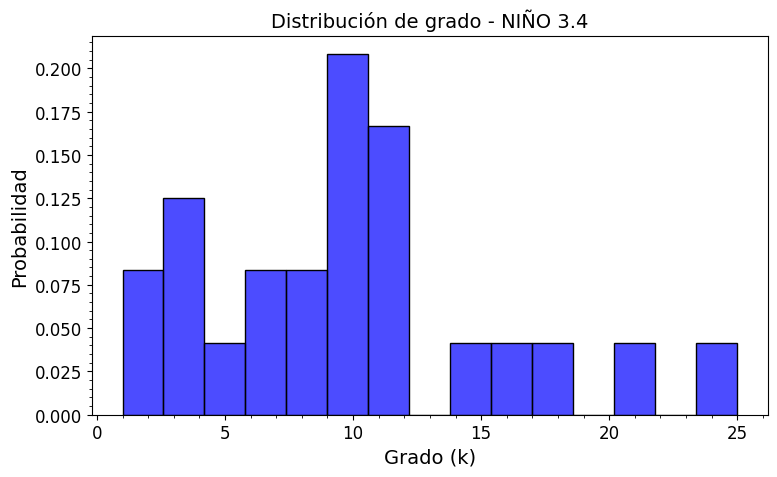

Distribución de grado - NIÑO 3.4
  Estadísticas: media=9.8333, varianza=34.2319, asimetría=0.8501, curtosis=0.4555
  Segundo momento ⟨k²⟩ = 129.5000
  Exponente γ = 2.7457 ± 0.4234 (xmin = 7.0)
  p-valor (vs. exponencial) = 0.0063
  Grado mínimo: 1, máximo: 25



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


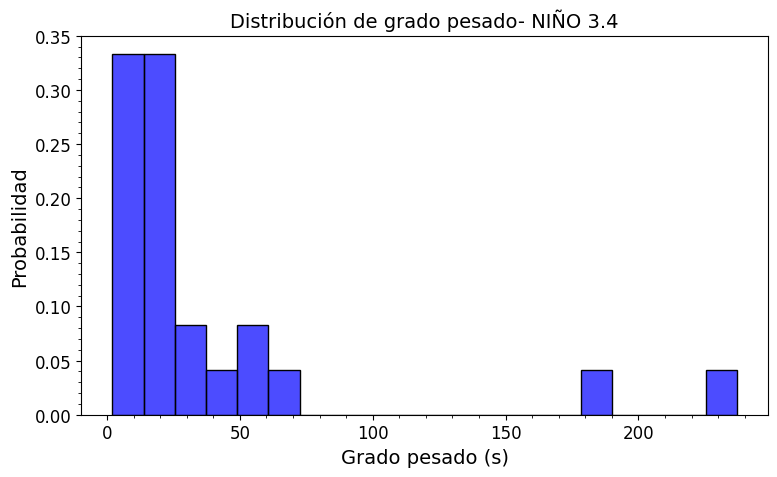

Distribución de grado pesado - NIÑO 3.4
  Estadísticas: media=36.5000, varianza=3235.6522, asimetría=2.6828, curtosis=6.2093
  Segundo momento ⟨s²⟩ = 4433.0833
  Exponente γ = 2.1284 ± 0.2821 (xmin = 14.0)
  p-valor (vs. exponencial) = 0.1195
  Fuerza mínima: 2.00, máxima: 237.00



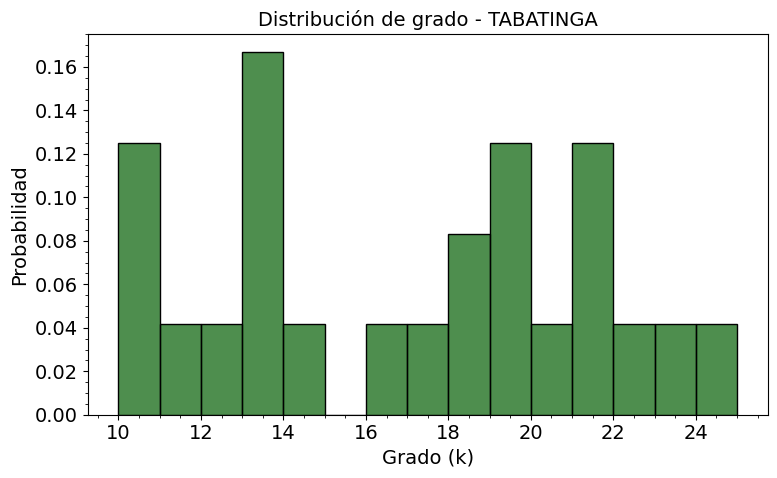

Distribución de grado - TABATINGA
  Estadísticas: media=16.5833, varianza=20.6014, asimetría=0.0181, curtosis=-1.2132
  Segundo momento ⟨k²⟩ = 294.7500
  Exponente γ = 2.9272 ± 0.3934 (xmin = 10.0)
  p-valor (vs. exponencial) = 0.0004
  Grado mínimo: 10, máximo: 25



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')


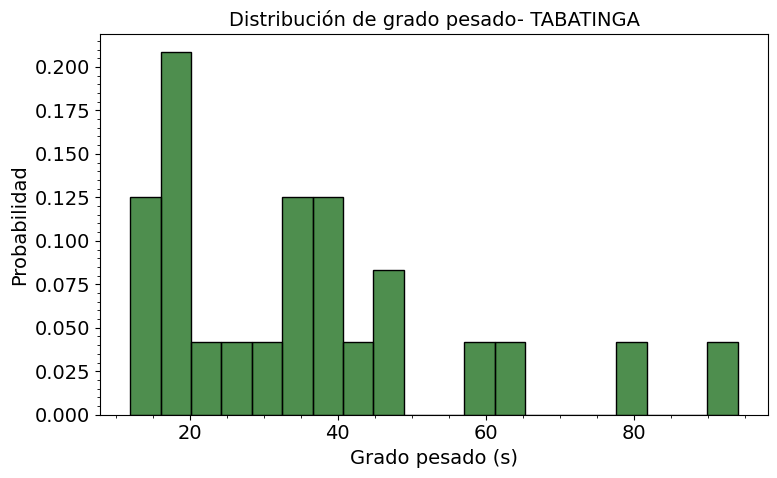

Distribución de grado pesado - TABATINGA
  Estadísticas: media=36.5000, varianza=441.7391, asimetría=1.1472, curtosis=0.8811
  Segundo momento ⟨s²⟩ = 1755.5833
  Exponente γ = 2.0382 ± 0.2119 (xmin = 12.0)
  p-valor (vs. exponencial) = 0.0101
  Fuerza mínima: 12.00, máxima: 94.00



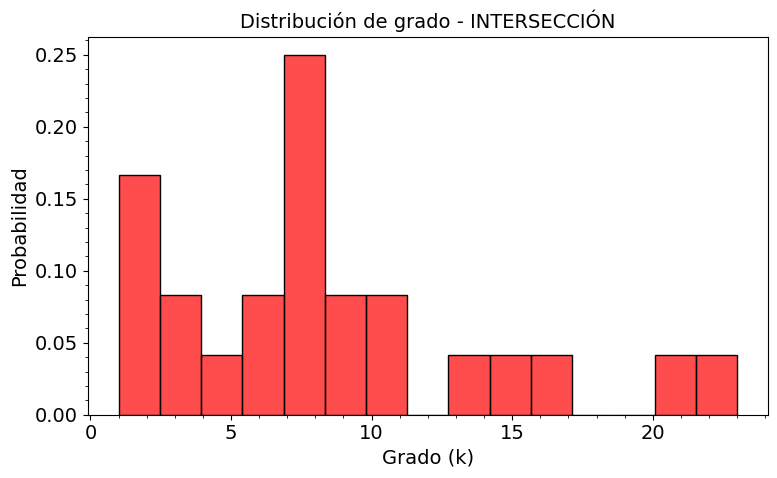

Distribución de grado - INTERSECCIÓN
  Estadísticas: media=8.4167, varianza=34.2536, asimetría=0.9441, curtosis=0.3968
  Segundo momento ⟨k²⟩ = 103.6667
  Exponente γ = 2.6982 ± 0.4119 (xmin = 6.0)
  p-valor (vs. exponencial) = 0.1096
  Grado mínimo: 1, máximo: 23



/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/entorno_trabajo_grado/lib/python3.12/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution exponential; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


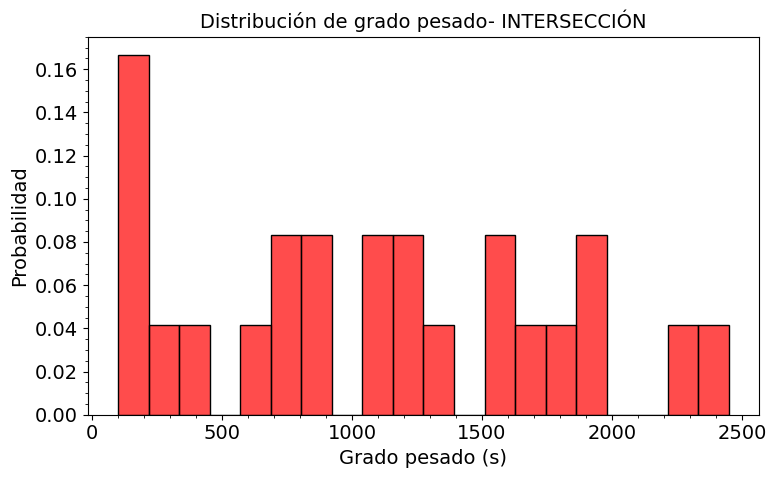

Distribución de grado pesado - INTERSECCIÓN
  Estadísticas: media=1099.0003, varianza=478213.1534, asimetría=0.1878, curtosis=-0.9765
  Segundo momento ⟨s²⟩ = 1666089.1920
  Exponente γ = 2.7685 ± 0.4289 (xmin = 767.8571428571429)
  p-valor (vs. exponencial) = 0.0486
  Fuerza mínima: 100.00, máxima: 2449.44



In [34]:
# Suponiendo que tienes G, G1 y GC definidos
plot_degree_distribution(G, "NIÑO 3.4", color='blue', bins=15, loglog=False)
plot_degree_distribution_pesada(G, "NIÑO 3.4", color='blue', bins=20, loglog=False)

plot_degree_distribution(G1, "TABATINGA", color='#035e03', bins=15, loglog=False)
plot_degree_distribution_pesada(G1, "TABATINGA", color='#035e03', bins=20, loglog=False)

plot_degree_distribution(GC, "INTERSECCIÓN", color='red', bins=15, loglog=False)
plot_degree_distribution_pesada(GC, "INTERSECCIÓN", color='red', bins=20, loglog=False)

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def correlacion_pearson(x, y, nombre_x='Serie X', nombre_y='Serie Y'):
    """
    Calcula la correlación de Pearson entre dos series y genera una gráfica de dispersión.

    Parámetros:
    x, y : listas o arrays unidimensionales de la misma longitud.
    nombre_x, nombre_y : etiquetas para los ejes.

    Retorna:
    r : coeficiente de correlación de Pearson.
    p : valor p asociado.
    """
    x = np.array(x)
    y = np.array(y)
    if len(x) != len(y):
        raise ValueError("Las series deben tener la misma longitud")

    # Calcular correlación de Pearson
    r, p = stats.pearsonr(x, y)

    # Ajuste lineal para la recta de regresión
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # Crear gráfica
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=0.6, edgecolors='k', linewidth=0.5)
    # Recta de regresión
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = slope * x_line + intercept
    plt.plot(x_line, y_line, 'r-', label=f'Regresión lineal (r={r:.3f})')
    plt.xlabel(nombre_x)
    plt.ylabel(nombre_y)
    #plt.title(f'Correlación de Pearson: r={r:.3f}, p={p:.3e}')
    #plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 14,
    'axes.labelsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14
})
    plt.show()

    print(f"Coeficiente de correlación de Pearson: r = {r:.4f}")
    print(f"Valor p: {p:.4e}")
    return r, p

##PEARSON

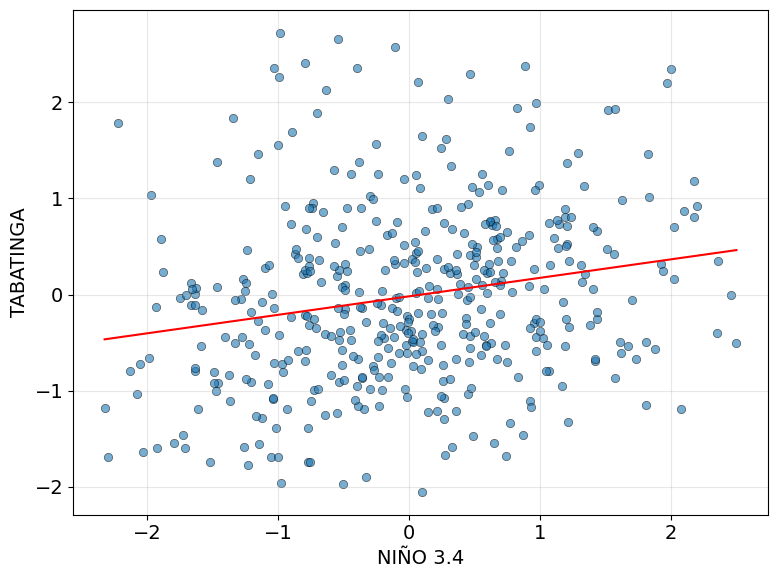

Coeficiente de correlación de Pearson: r = 0.2075
Valor p: 1.0228e-05


In [36]:
# Suponiendo que tienes las series x (NIÑO) y x1 (CALAMAR) definidas
r, p = correlacion_pearson(x1, x, nombre_y='TABATINGA', nombre_x='NIÑO 3.4')

##BOOTSTRAP

In [37]:
porcentaje_para_comparar=promedio
print(porcentaje_para_comparar)

22.895838894385253


Resultados del bootstrap clásico sobre x1 (1000 remuestras):
Media: 19.15
Mediana: 19.12
Desviación estándar: 1.61
Intervalo de confianza 95%: (16.13, 22.31)
Distancia del observado respecto a la media bootstrap: 2.33 desviaciones estándar


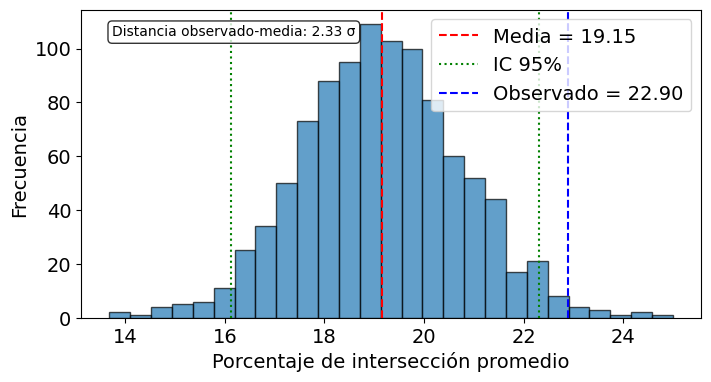

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros
w_opt = 4
n_bootstrap = 1000          # número de remuestras
np.random.seed(42)          # para reproducibilidad

# Asegurarse de que A (matriz del niño) está calculada a partir de x
# Si no lo está, calcúlala aquí:
# nodos_x = crear_ind(x, w_opt)
# G_x, _, _ = crear_grafo(nodos_x, w_opt)
# A = nx.to_numpy_array(G_x, dtype=int)

# Lista para almacenar los resultados
porcents_boot = []

for i in range(n_bootstrap):
    # 1. Remuestrear x1 con reemplazo (bootstrap clásico)
    indices_boot = np.random.choice(len(x1), size=len(x1), replace=True)
    x1_boot = [x1[i] for i in indices_boot]   # si x1 es lista
    # Si x1 es array de numpy: x1_boot = x1[indices_boot]

    # 2. Obtener índices de patrones ordinales de la remuestra
    nodos_boot = crear_ind(x1_boot, w_opt)

    # 3. Construir grafo y matriz de adyacencia
    G_boot, _, _ = crear_grafo(nodos_boot, w_opt)
    A_boot = nx.to_numpy_array(G_boot, dtype=int)

    # 4. Calcular la métrica de similitud con A (la red del niño)
    with np.errstate(divide='ignore', invalid='ignore'):
        C = np.divide(A_boot, A, out=np.zeros_like(A, dtype=float), where=A != 0) * 100
    C_clean = np.where(np.isinf(C), 0, C)
    upper = np.triu(C_clean, k=1)          # triángulo superior sin diagonal
    promedio = np.mean(upper)               # promedio de todas las celdas (incluye ceros)
    # Si prefieres solo celdas con valor positivo:
    # promedio = np.mean(upper[upper > 0]) if np.any(upper > 0) else 0

    porcents_boot.append(promedio)

porcents_boot = np.array(porcents_boot)

# Estadísticos
media_boot = np.mean(porcents_boot)
mediana_boot = np.median(porcents_boot)
desv_boot = np.std(porcents_boot, ddof=1)
ic_inf = np.percentile(porcents_boot, 2.5)
ic_sup = np.percentile(porcents_boot, 97.5)
# Distancia del valor observado respecto a la media bootstrap (en desviaciones estándar)
distancia_sd = (porcentaje_para_comparar - media_boot) / desv_boot


print(f"Resultados del bootstrap clásico sobre x1 ({n_bootstrap} remuestras):")
print(f"Media: {media_boot:.2f}")
print(f"Mediana: {mediana_boot:.2f}")
print(f"Desviación estándar: {desv_boot:.2f}")
print(f"Intervalo de confianza 95%: ({ic_inf:.2f}, {ic_sup:.2f})")
print(f"Distancia del observado respecto a la media bootstrap: {distancia_sd:.2f} desviaciones estándar")

# Histograma
plt.figure(figsize=(8,4))
plt.hist(porcents_boot, bins='auto', alpha=0.7, edgecolor='black')
plt.axvline(media_boot, color='red', linestyle='--', label=f'Media = {media_boot:.2f}')
plt.axvline(ic_inf, color='green', linestyle=':', label='IC 95%')
plt.axvline(ic_sup, color='green', linestyle=':')
plt.axvline(porcentaje_para_comparar, color='blue', linestyle='--', label=f'Observado = {porcentaje_para_comparar:.2f}')
#plt.title('Distribución bootstrap de la similitud (A vs remuestras de x1)')
# Agregar anotación con la distancia en SD (opción con recuadro)
plt.text(0.05, 0.95, f'Distancia observado-media: {distancia_sd:.2f} σ',
         transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.xlabel('Porcentaje de intersección promedio')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()


  Red: Niño 3.4  (n = 24 nodos activos)
  x̂_min  = 14.0
  α̂      = 2.1284  ±  0.2821  (1σ)
  KS obs = 0.0931
  n_tail = 16  (puntos en la cola de ley de potencias)
  p-valor MC (2500 sims) = 0.938  →  ley de potencias PLAUSIBLE  ✓
  (Regla del paper: rechazar si p ≤ 0.1)

  Red: Caudal Óbidos  (n = 24 nodos activos)
  x̂_min  = 36.0
  α̂      = 4.4199  ±  0.9485  (1σ)
  KS obs = 0.1538
  n_tail = 13  (puntos en la cola de ley de potencias)
  p-valor MC (2500 sims) = 0.598  →  ley de potencias PLAUSIBLE  ✓
  (Regla del paper: rechazar si p ≤ 0.1)


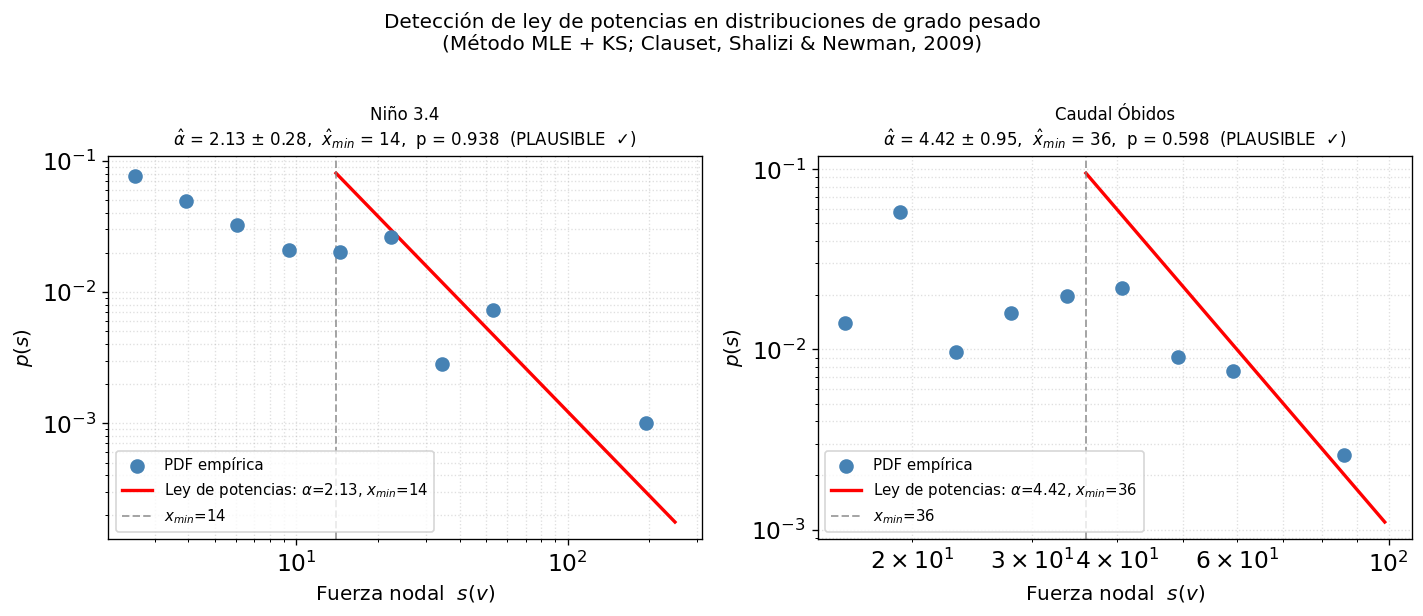


  RESUMEN COMPARATIVO
Métrica                       Niño 3.4       Óbidos
-------------------------------------------------------
  x̂_min                            14           36
  α̂                            2.1284       4.4199
  σ(α̂)                         0.2821       0.9485
  KS                            0.0931       0.1538
  n_tail                            16           13
  p-valor MC                    0.9380       0.5980

Criterio: p > 0.1  →  ley de potencias plausible
          p ≤ 0.1  →  ley de potencias rechazada


In [39]:
# ============================================================
# DETECCIÓN DE LEY DE POTENCIAS EN DISTRIBUCIONES DE GRADO PESADO
# Método: PDF con ajuste MLE (Clauset, Shalizi & Newman, 2009)
# Sección 3 + Sección 4 del paper
# ============================================================
#
# El paper advierte que el método más común —trazar el histograma
# en escala log-log y ajustar por regresión lineal (LS)— produce
# estimaciones sistemáticamente sesgadas de α (ver Tabla 3.1).
# El enfoque correcto es:
#   1. Estimar x_min con el estadístico KS (Ec. 3.9).
#   2. Estimar α con el MLE continuo (Ec. 3.1) o discreto (Ec. 3.7).
#   3. Calcular la bondad de ajuste mediante Monte Carlo (Sección 4).
#   4. Visualizar la PDF en escala log-log junto con el ajuste.
#
# Aquí la "distribución de grado pesado" es la distribución de
# FUERZAS nodales s(v) = Σ_u w(v,u) en cada red de partición ordinal.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import zeta as hurwitz_zeta   # ζ(α, x_min)
from scipy.optimize import minimize_scalar

# ------------------------------------------------------------------
# 0. Extraer fuerzas nodales de los grafos G y G1
# ------------------------------------------------------------------
fuerzas_nino  = np.array([d for _, d in G.degree(weight='weight')],  dtype=float)
fuerzas_obidos = np.array([d for _, d in G1.degree(weight='weight')], dtype=float)

# Excluir nodos aislados (fuerza = 0) que no aportan información de escala
fuerzas_nino   = fuerzas_nino[fuerzas_nino > 0]
fuerzas_obidos = fuerzas_obidos[fuerzas_obidos > 0]

# ------------------------------------------------------------------
# 1. Herramientas estadísticas (Clauset et al., 2009)
# ------------------------------------------------------------------

def mle_alpha_continuo(data, xmin):
    """
    Estimador de máxima verosimilitud para α en distribución de
    ley de potencias continua (Ec. 3.1 del paper):
        α̂ = 1 + n [Σ ln(x_i / x_min)]^{-1}
    Equivalente al estimador de Hill (asintóticamente normal y consistente).
    """
    x = data[data >= xmin]
    n = len(x)
    if n < 2:
        return np.nan
    alpha = 1.0 + n / np.sum(np.log(x / xmin))
    return alpha

def error_estandar_alpha(alpha, n):
    """
    Error estándar del MLE (Ec. 3.2):  σ = (α̂ - 1) / √n
    """
    return (alpha - 1.0) / np.sqrt(n)

def ks_distancia(data, xmin, alpha):
    """
    Estadístico KS entre la CDF empírica y la CDF teórica de la ley
    de potencias continua (Ec. 3.9):  D = max_{x ≥ x_min} |S(x) - P(x)|
    donde P(x) = (x / x_min)^{-α+1}
    """
    x = np.sort(data[data >= xmin])
    n = len(x)
    if n == 0:
        return np.inf
    # CDF empírica S(x): fracción de datos ≥ cada valor observado
    S = 1.0 - np.arange(n) / n          # S(x_i) = (n-i)/n  (complementaria)
    # CDF teórica P(x) = (x / x_min)^{-α+1}
    P = (x / xmin) ** (-alpha + 1.0)
    P = np.clip(P, 0.0, 1.0)
    return np.max(np.abs(S - P))

def estimar_xmin_ks(data):
    """
    Selecciona x̂_min minimizando el estadístico KS sobre todos los
    candidatos únicos (método de Clauset et al., Sec. 3.3).
    Devuelve (x_min_opt, alpha_opt, D_min).
    """
    candidatos = np.unique(data)
    # No tiene sentido probar los dos últimos valores (quedarían < 2 puntos)
    candidatos = candidatos[:-2] if len(candidatos) > 2 else candidatos

    mejor_D     = np.inf
    mejor_xmin  = candidatos[0]
    mejor_alpha = np.nan

    for xc in candidatos:
        alpha = mle_alpha_continuo(data, xc)
        if np.isnan(alpha) or alpha <= 1.0:
            continue
        D = ks_distancia(data, xc, alpha)
        if D < mejor_D:
            mejor_D     = D
            mejor_xmin  = xc
            mejor_alpha = alpha

    return mejor_xmin, mejor_alpha, mejor_D

def pvalor_montecarlo(data, xmin, alpha, n_sims=2500, seed=42):
    """
    Calcula el p-valor por Monte Carlo (Sección 4 del paper).
    Genera n_sims conjuntos sintéticos semiparam. y cuenta cuántas veces
    su KS supera el observado.
    Regla del paper: p > 0.1 → ley de potencias plausible.
    """
    rng = np.random.default_rng(seed)
    n_total  = len(data)
    n_tail   = int(np.sum(data >= xmin))
    n_body   = n_total - n_tail
    datos_body = data[data < xmin]

    D_obs = ks_distancia(data, xmin, alpha)

    cuenta = 0
    for _ in range(n_sims):
        # Generar cola sintética: x = x_min * u^{-1/(α-1)}  (Apéndice D, Ec. D.4)
        u     = rng.uniform(0, 1, n_tail)
        cola  = xmin * (1.0 - u) ** (-1.0 / (alpha - 1.0))

        # Cuerpo: remuestreo con reemplazo de los datos empíricos por debajo de x_min
        if n_body > 0:
            cuerpo = rng.choice(datos_body, size=n_body, replace=True)
            sintetico = np.concatenate([cola, cuerpo])
        else:
            sintetico = cola

        # Ajustar ley de potencias al conjunto sintético
        alpha_s = mle_alpha_continuo(sintetico, xmin)
        if np.isnan(alpha_s) or alpha_s <= 1.0:
            continue
        D_s = ks_distancia(sintetico, xmin, alpha_s)
        if D_s >= D_obs:
            cuenta += 1

    return cuenta / n_sims

def pdf_powerlaw_continua(x, xmin, alpha):
    """
    PDF de la ley de potencias continua (Ec. 2.2):
        p(x) = (α-1)/x_min * (x/x_min)^{-α}    para x ≥ x_min
    """
    p = np.zeros_like(x, dtype=float)
    mask = x >= xmin
    p[mask] = (alpha - 1.0) / xmin * (x[mask] / xmin) ** (-alpha)
    return p

# ------------------------------------------------------------------
# 2. Ajuste y diagnóstico para cada red
# ------------------------------------------------------------------

def analizar_distribucion(fuerzas, nombre, n_sims=2500, ax=None):
    """
    Aplica el método completo de Clauset et al. (2009) a un array
    de fuerzas nodales e imprime resultados.  Dibuja en ax si se pasa.
    """
    print(f"\n{'='*55}")
    print(f"  Red: {nombre}  (n = {len(fuerzas)} nodos activos)")
    print(f"{'='*55}")

    # --- Paso 1: estimar x_min y α ---
    xmin, alpha, D_obs = estimar_xmin_ks(fuerzas)
    n_tail = int(np.sum(fuerzas >= xmin))
    sigma  = error_estandar_alpha(alpha, n_tail)

    print(f"  x̂_min  = {xmin:.1f}")
    print(f"  α̂      = {alpha:.4f}  ±  {sigma:.4f}  (1σ)")
    print(f"  KS obs = {D_obs:.4f}")
    print(f"  n_tail = {n_tail}  (puntos en la cola de ley de potencias)")

    # --- Paso 2: bondad de ajuste por Monte Carlo ---
    # Precisión ~0.02 con 2500 simulaciones (ver Sec. 4.1 del paper)
    p = pvalor_montecarlo(fuerzas, xmin, alpha, n_sims=n_sims)
    veredicto = "PLAUSIBLE  ✓" if p > 0.1 else "RECHAZADA  ✗"
    print(f"  p-valor MC ({n_sims} sims) = {p:.3f}  →  ley de potencias {veredicto}")
    print(f"  (Regla del paper: rechazar si p ≤ 0.1)")

    # --- Paso 3: visualización PDF en escala log-log ---
    if ax is not None:
        # Histograma logarítmico (logarithmic binning) de la PDF empírica
        # Evita el sesgo de bins de ancho constante (ver Apéndice A del paper)
        datos_pos = fuerzas[fuerzas > 0]
        log_min = np.log10(datos_pos.min())
        log_max = np.log10(datos_pos.max())
        bins = np.logspace(log_min, log_max, num=12)

        counts, edges = np.histogram(datos_pos, bins=bins)
        widths   = np.diff(edges)
        centers  = 0.5 * (edges[:-1] + edges[1:])
        pdf_emp  = counts / (len(datos_pos) * widths)   # densidad normalizada

        mask_pos = counts > 0
        ax.scatter(centers[mask_pos], pdf_emp[mask_pos],
                   color='steelblue', s=60, zorder=3, label='PDF empírica')

        # Curva teórica de ley de potencias para x ≥ x_min
        x_fit = np.linspace(xmin, datos_pos.max() * 1.05, 300)
        y_fit = pdf_powerlaw_continua(x_fit, xmin, alpha)
        # Escalar para que la integral sobre el rango observado coincida
        # La normalización ya es correcta desde Ec. 2.2
        ax.plot(x_fit, y_fit, 'r-', lw=2,
                label=rf'Ley de potencias: $\alpha$={alpha:.2f}, $x_{{min}}$={xmin:.0f}')

        # Línea vertical en x_min
        ax.axvline(xmin, color='gray', ls='--', lw=1.2, alpha=0.7, label=f'$x_{{min}}$={xmin:.0f}')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Fuerza nodal  $s(v)$', fontsize=12)
        ax.set_ylabel('$p(s)$', fontsize=12)
        ax.set_title(f'{nombre}\n'
                     rf'$\hat{{\alpha}}$ = {alpha:.2f} ± {sigma:.2f},  '
                     rf'$\hat{{x}}_{{min}}$ = {xmin:.0f},  '
                     f'p = {p:.3f}  ({veredicto})',
                     fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, which='both', ls=':', alpha=0.4)

    return dict(xmin=xmin, alpha=alpha, sigma=sigma, D=D_obs,
                p=p, n_tail=n_tail)

# ------------------------------------------------------------------
# 3. Ejecutar análisis para las dos redes
# ------------------------------------------------------------------

plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 11,
    'figure.dpi': 120
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    'Detección de ley de potencias en distribuciones de grado pesado\n'
    '(Método MLE + KS; Clauset, Shalizi & Newman, 2009)',
    fontsize=12, y=1.02
)

res_nino   = analizar_distribucion(fuerzas_nino,   "Niño 3.4",     n_sims=2500, ax=axes[0])
res_obidos = analizar_distribucion(fuerzas_obidos, "Caudal Óbidos", n_sims=2500, ax=axes[1])

plt.tight_layout()
plt.savefig("powerlaw_grado_pesado.png", dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# 4. Tabla resumen comparativa
# ------------------------------------------------------------------
print("\n" + "="*55)
print("  RESUMEN COMPARATIVO")
print("="*55)
print(f"{'Métrica':<25} {'Niño 3.4':>12} {'Óbidos':>12}")
print("-"*55)
for key, label in [('xmin',   'x̂_min'),
                   ('alpha',  'α̂'),
                   ('sigma',  'σ(α̂)'),
                   ('D',      'KS'),
                   ('n_tail', 'n_tail'),
                   ('p',      'p-valor MC')]:
    v1 = res_nino[key]
    v2 = res_obidos[key]
    if key in ('xmin', 'n_tail'):
        s1 = f"{v1:.0f}"
        s2 = f"{v2:.0f}"
    else:
        s1 = f"{v1:.4f}"
        s2 = f"{v2:.4f}"
    print(f"  {label:<23} {s1:>12} {s2:>12}")
print("="*55)
print("\nCriterio: p > 0.1  →  ley de potencias plausible")
print("          p ≤ 0.1  →  ley de potencias rechazada")